In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"C:\Users\Acer_Nitro\Documents\Covid_19_data.csv")

In [3]:
df.head(50)

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,NaN,Afghanistan,1939,60,252
1,4/29/2020,NaN,Albania,766,30,455
2,4/29/2020,NaN,Algeria,3848,444,1702
3,4/29/2020,NaN,Andorra,743,42,423
4,4/29/2020,NaN,Angola,27,2,7
5,4/29/2020,NaN,Antigua and Barbuda,24,3,11
6,4/29/2020,NaN,Argentina,4285,214,1192
7,4/29/2020,NaN,Armenia,1932,30,900
8,4/29/2020,NaN,Austria,15402,580,12779
9,4/29/2020,NaN,Azerbaijan,1766,23,1267


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
imputer = SimpleImputer(strategy='constant')
df2 = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

In [6]:
df3 = df2.groupby(['Region', 'Date'])[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

In [7]:
df3.head(20)

,Region,Date,Confirmed,Deaths,Recovered
0,Afghanistan,2020-04-29,1939,60,252
1,Albania,2020-04-29,766,30,455
2,Algeria,2020-04-29,3848,444,1702
3,Andorra,2020-04-29,743,42,423
4,Angola,2020-04-29,27,2,7
5,Antigua and Barbuda,2020-04-29,24,3,11
6,Argentina,2020-04-29,4285,214,1192
7,Armenia,2020-04-29,1932,30,900
8,Australia,2020-04-29,6752,91,5715
9,Austria,2020-04-29,15402,580,12779


In [8]:
region = df3['Region'].unique()
len(region)

187

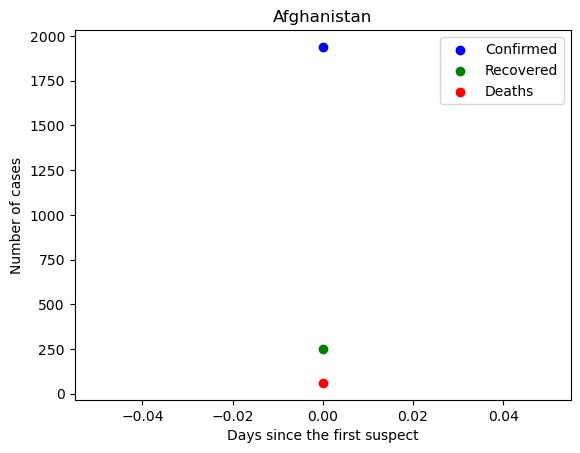

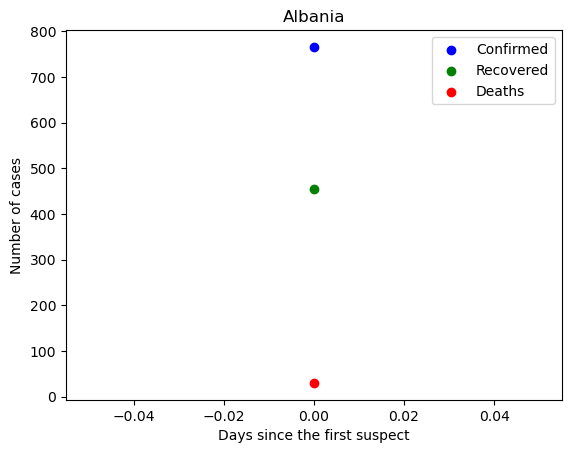

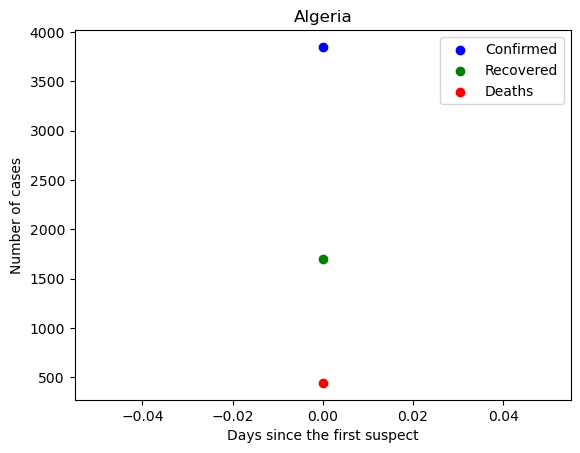

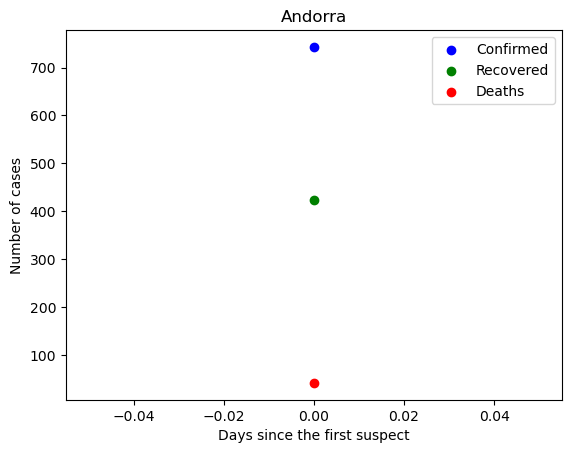

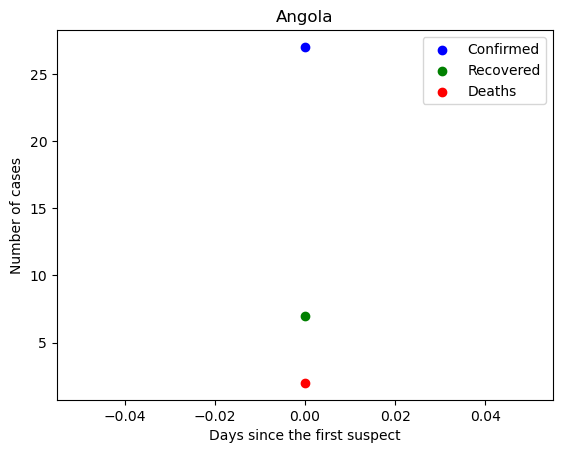

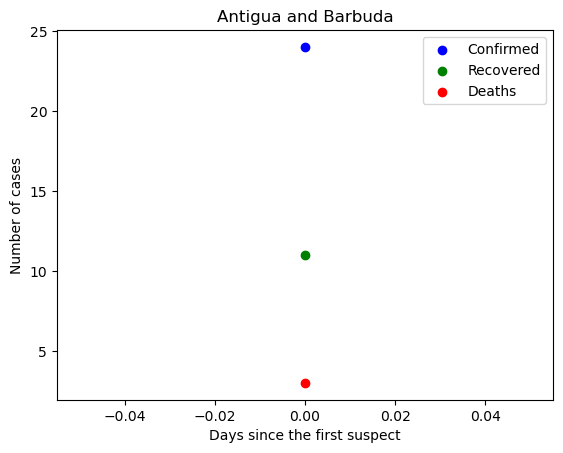

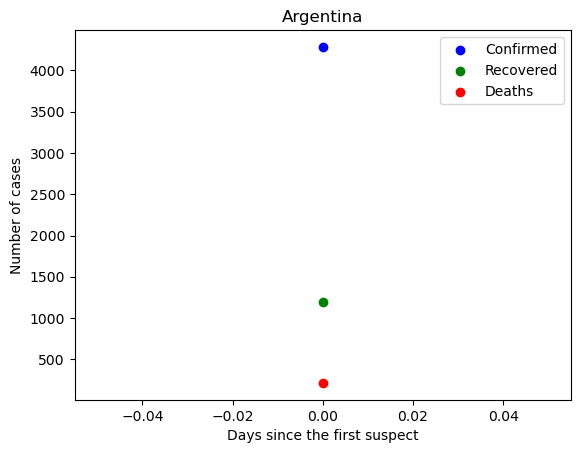

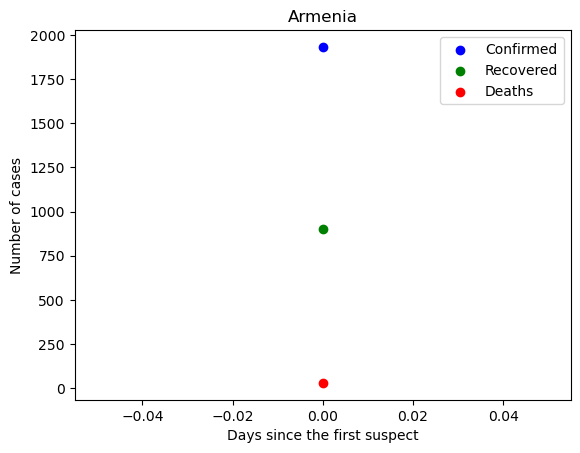

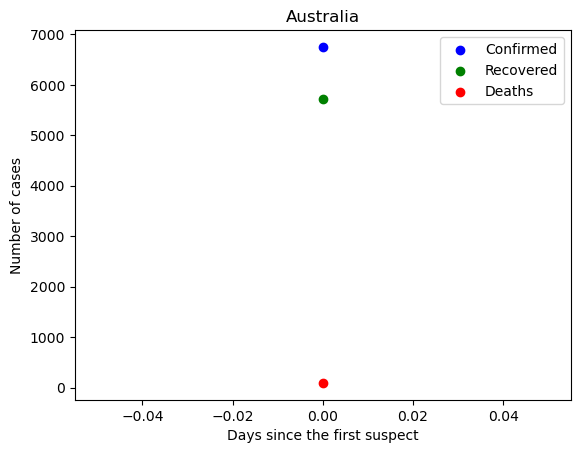

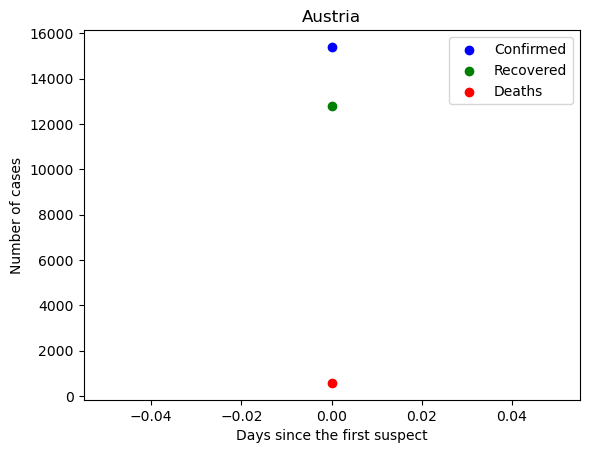

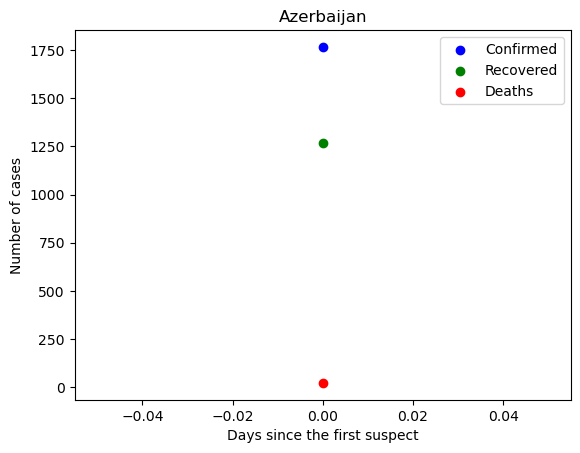

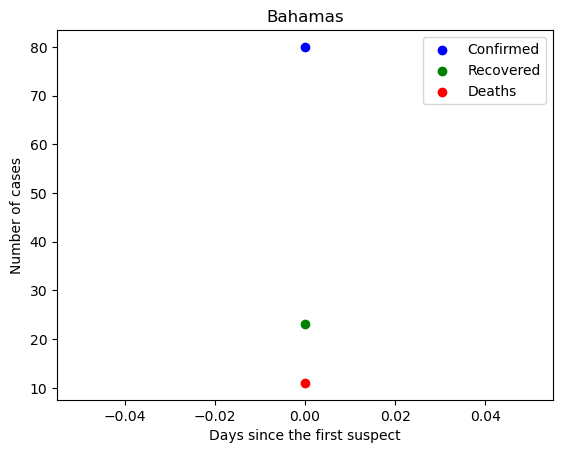

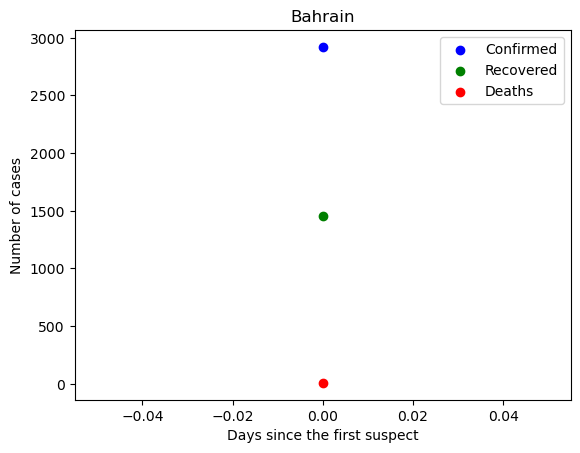

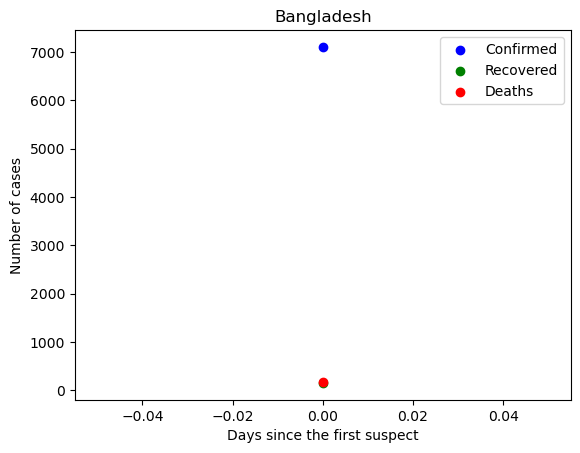

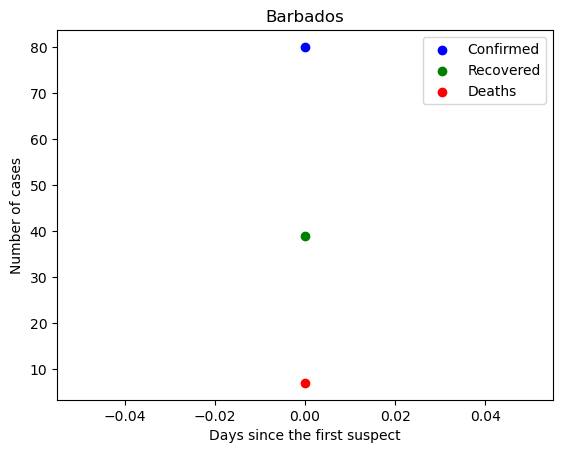

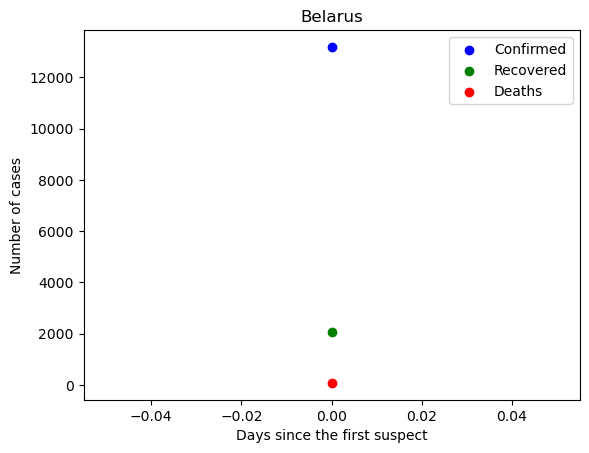

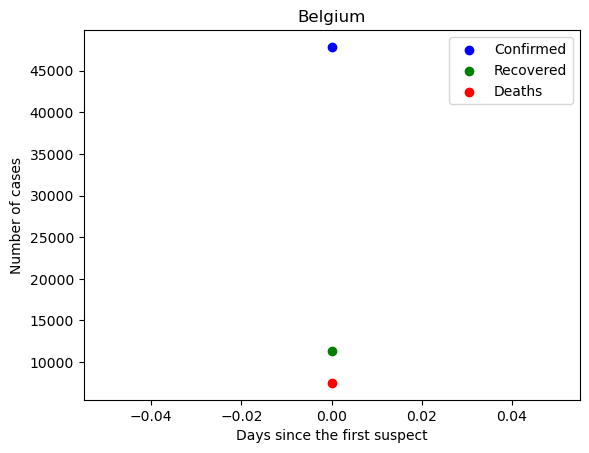

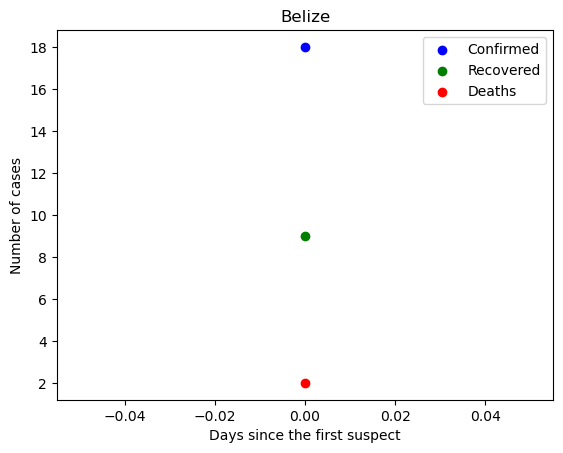

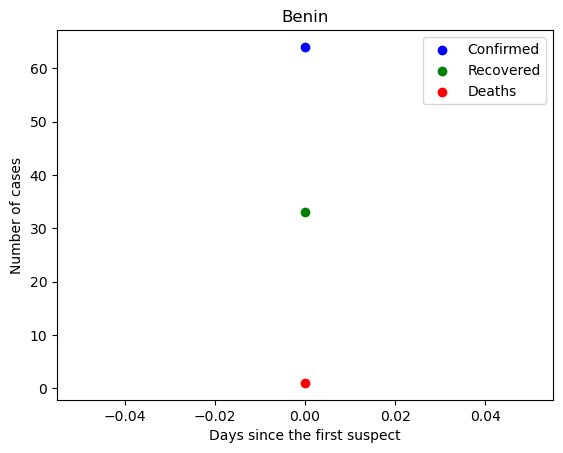

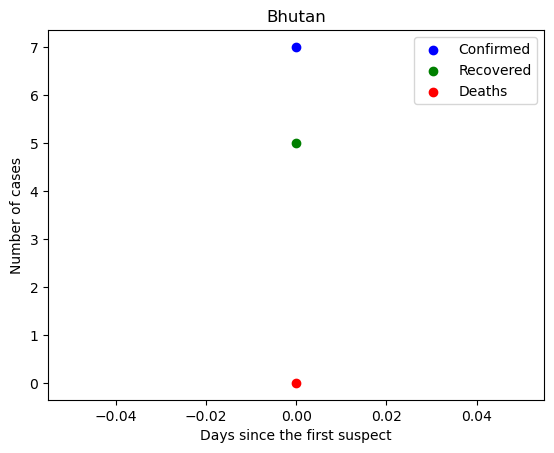

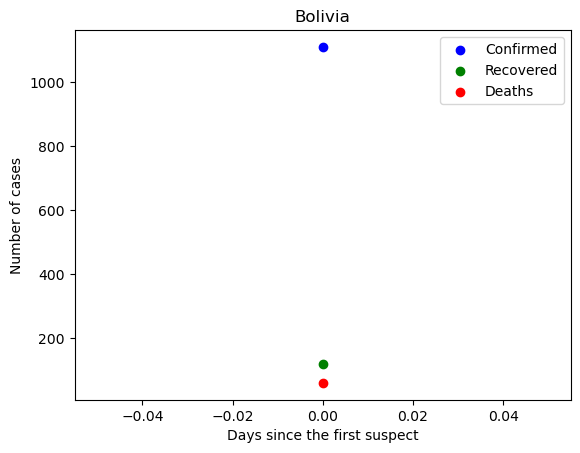

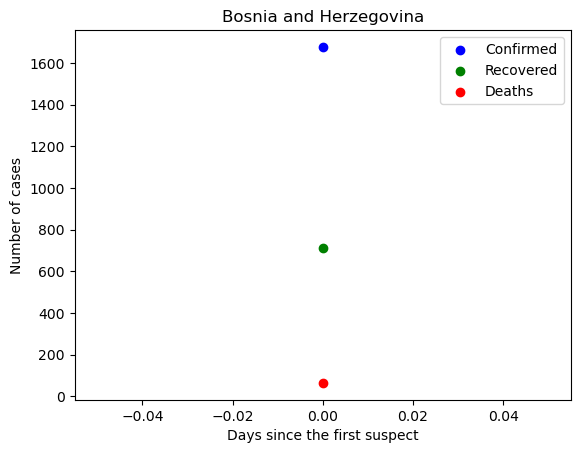

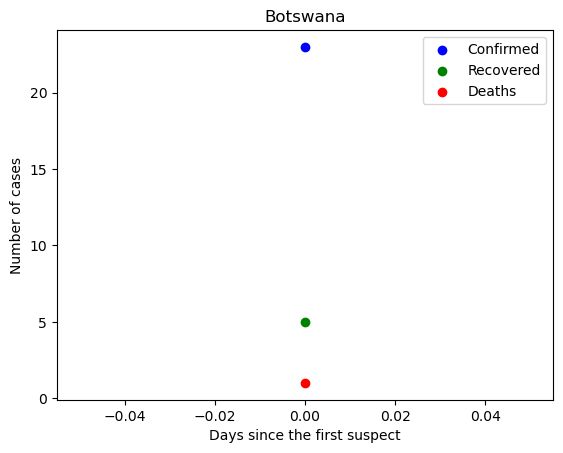

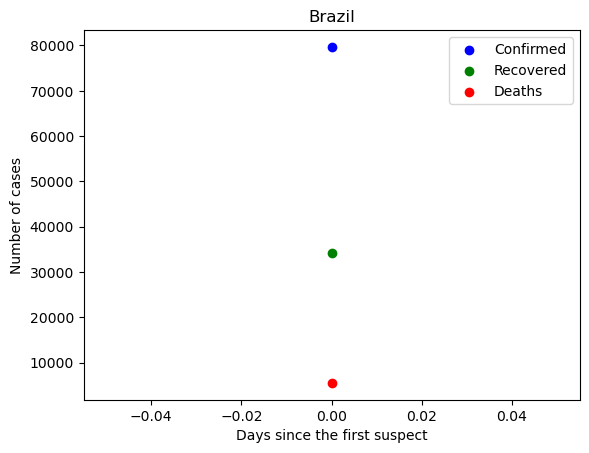

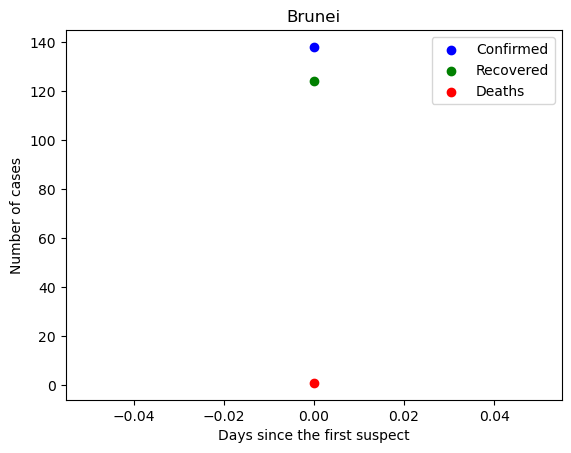

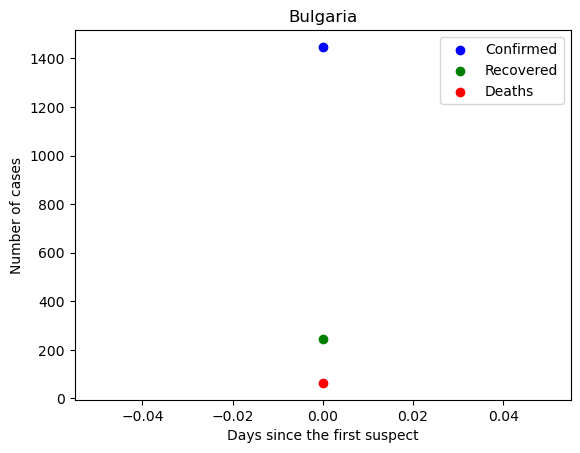

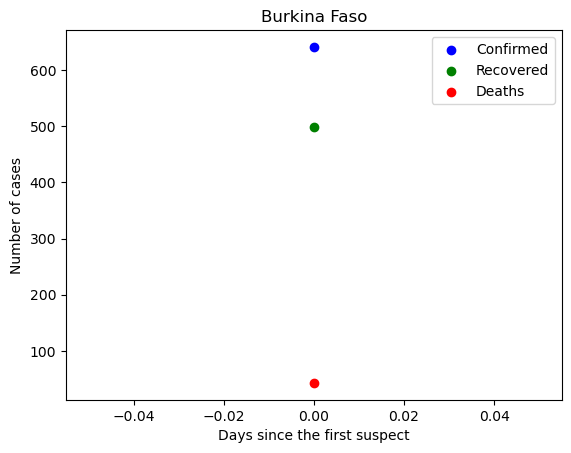

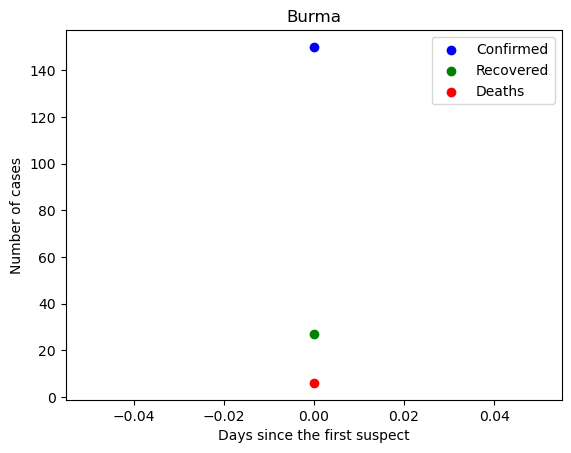

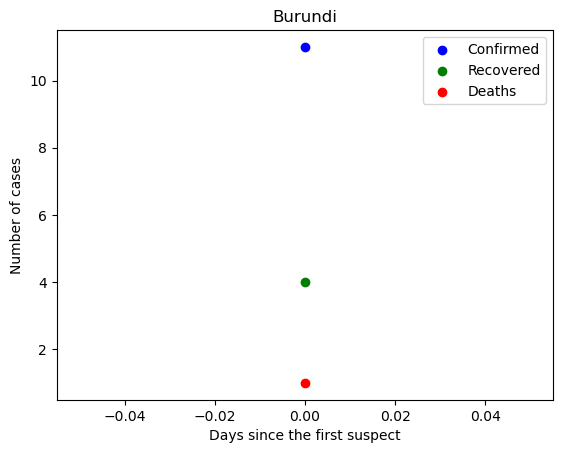

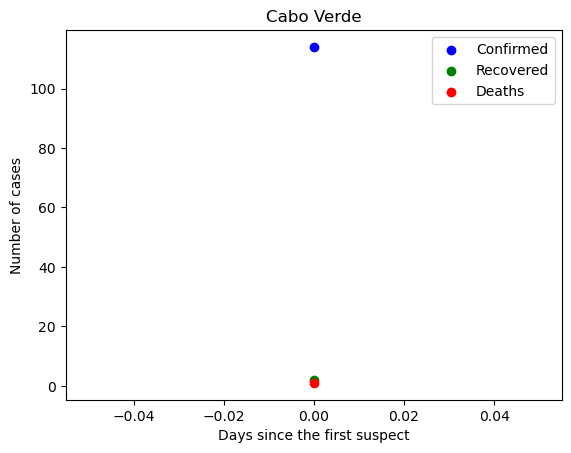

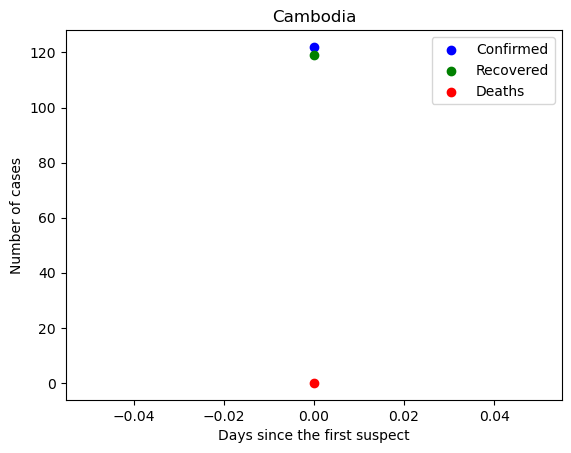

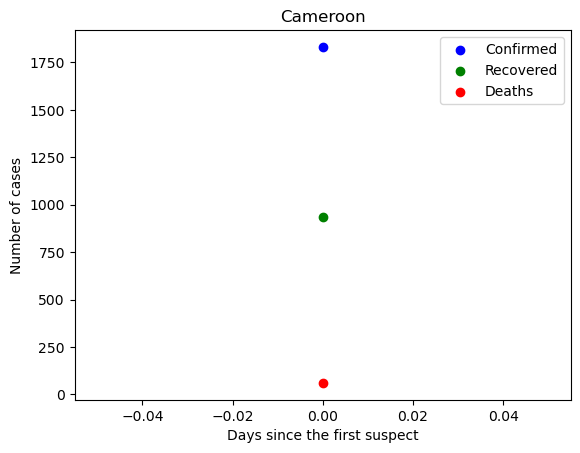

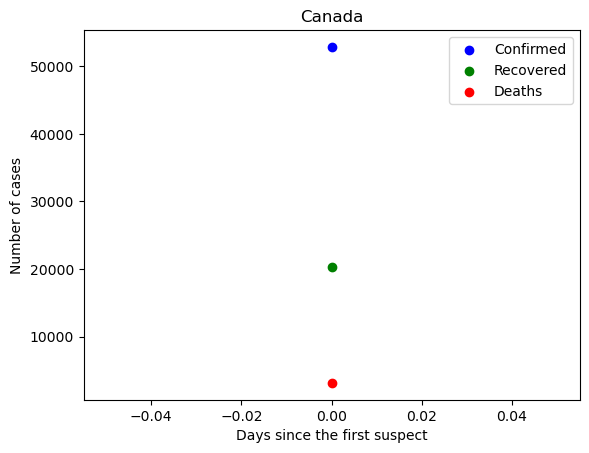

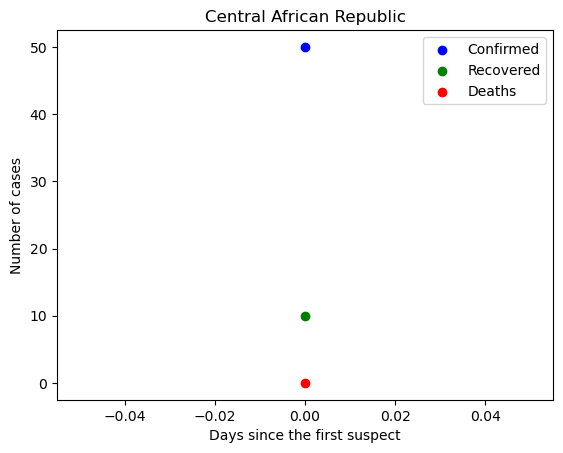

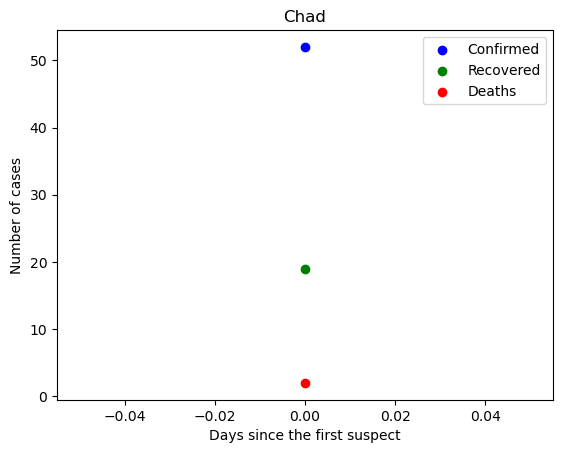

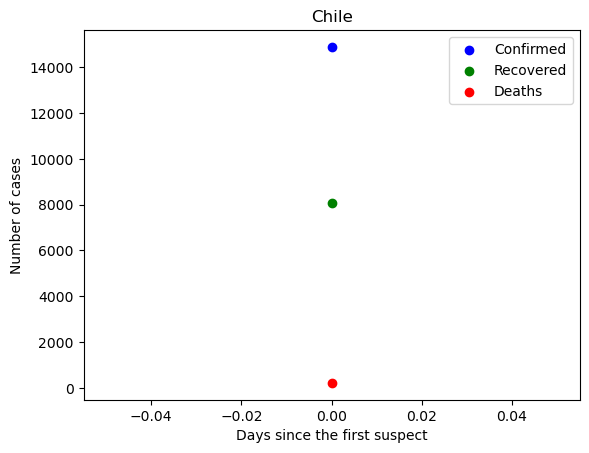

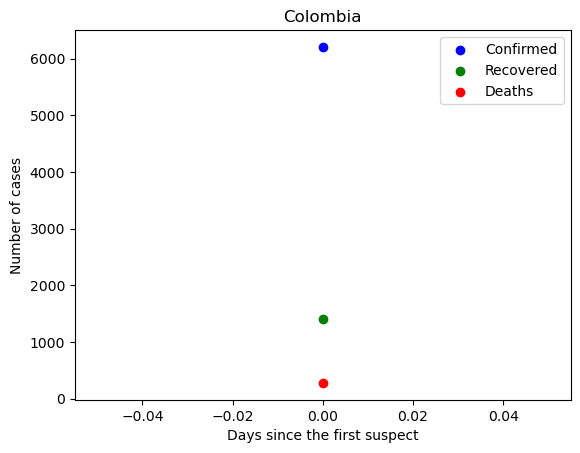

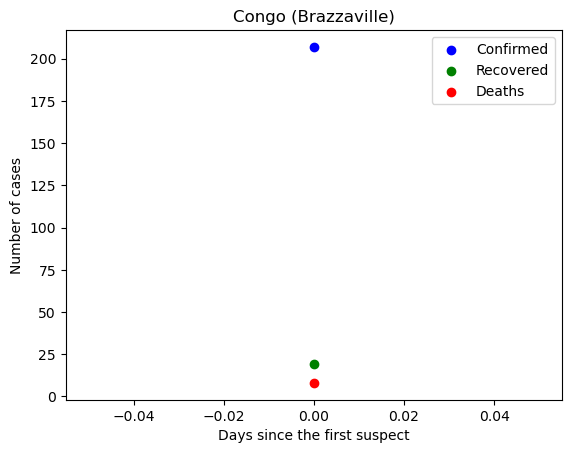

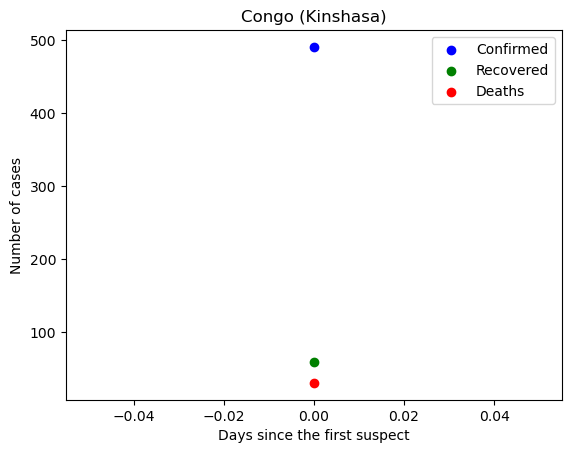

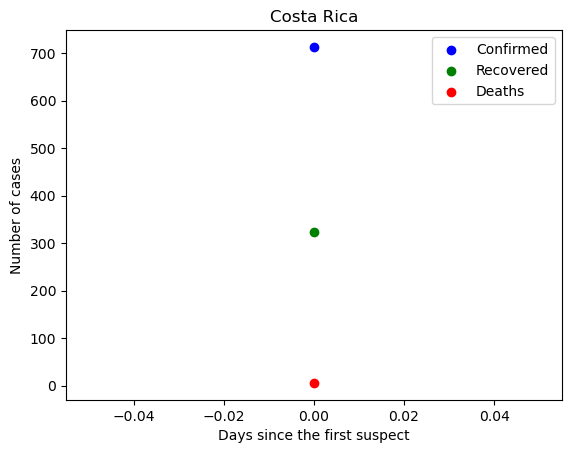

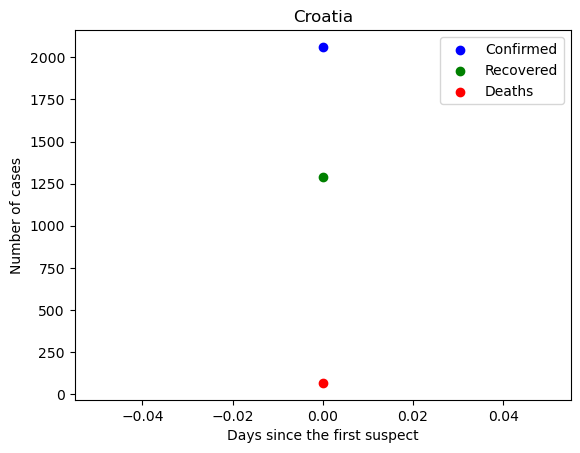

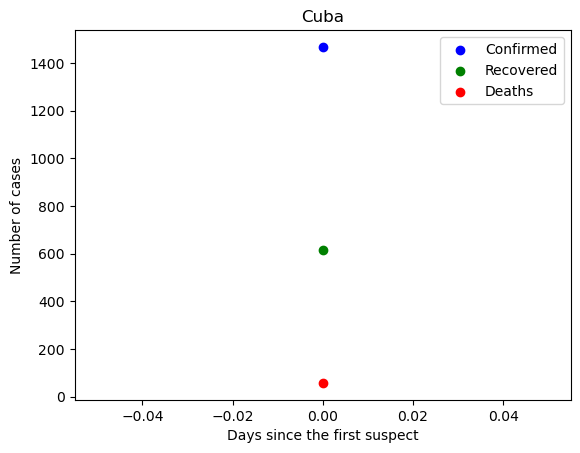

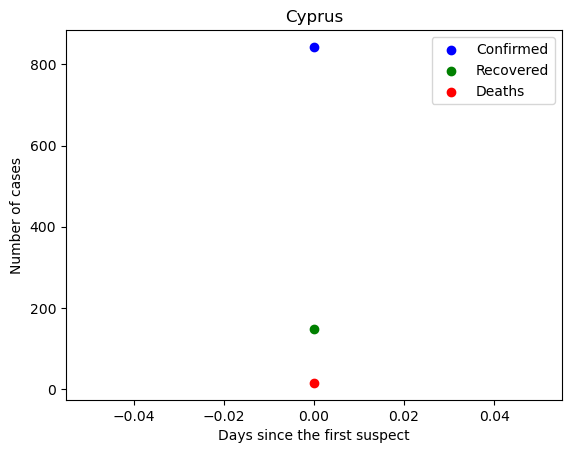

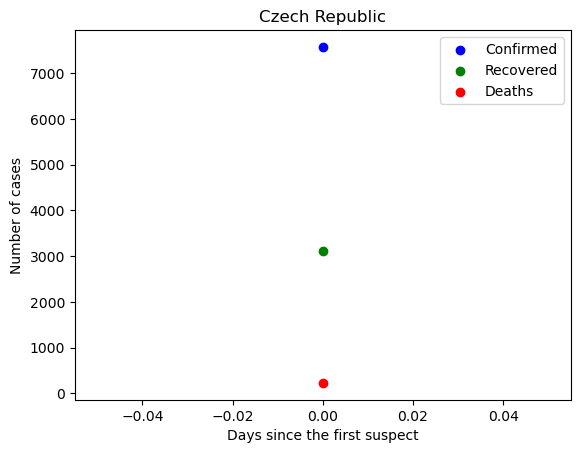

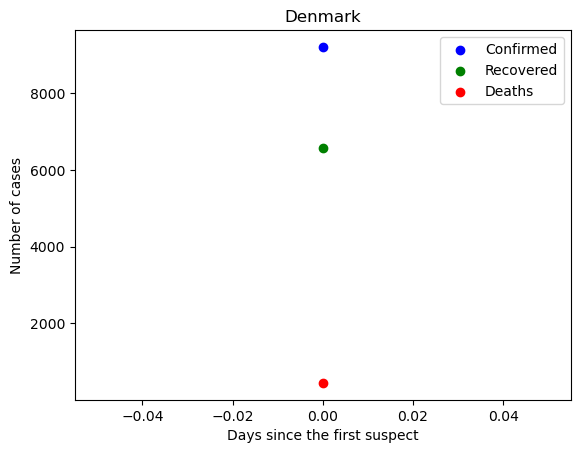

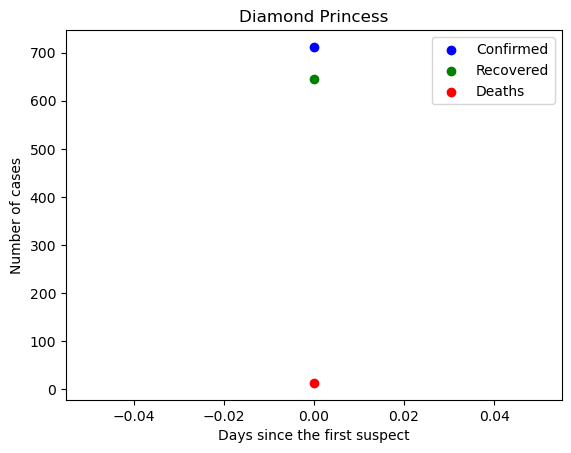

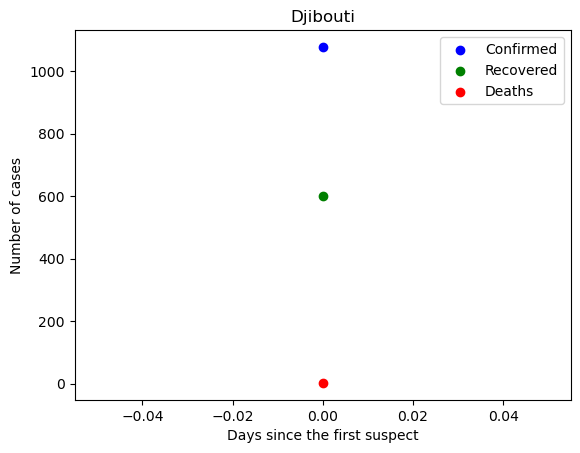

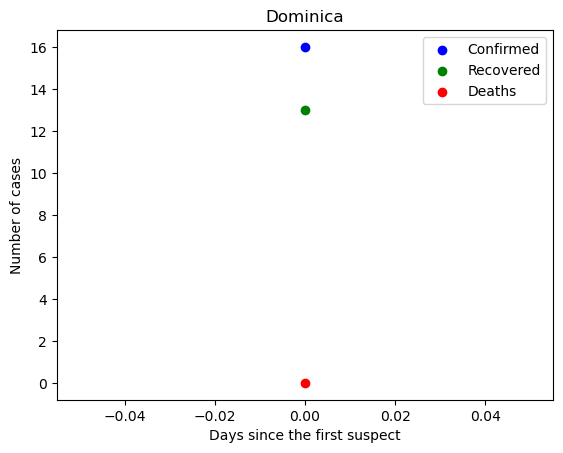

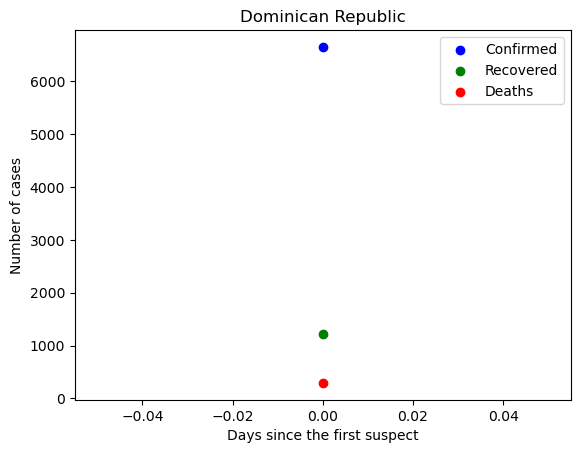

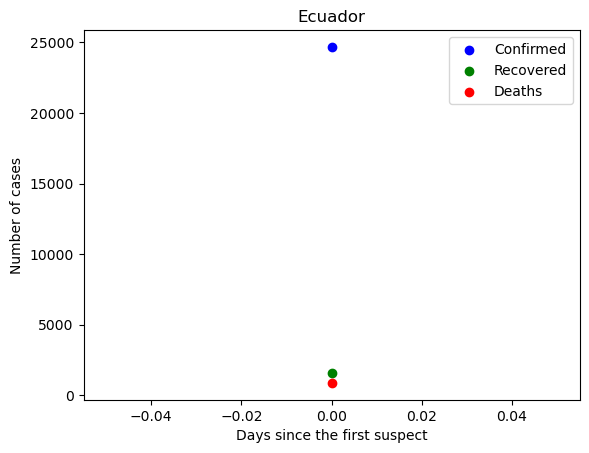

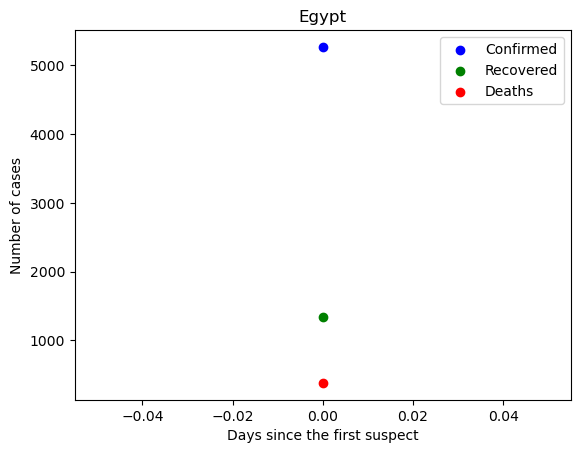

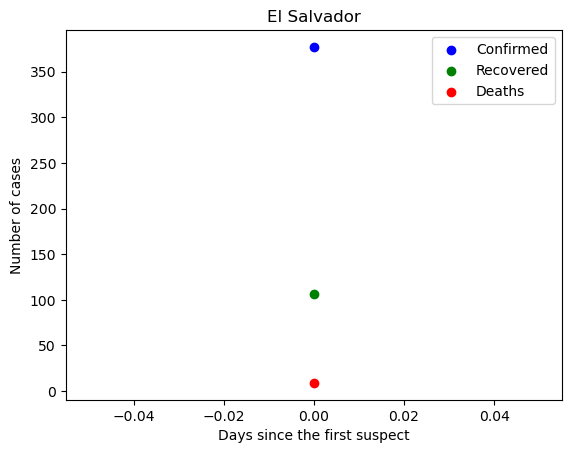

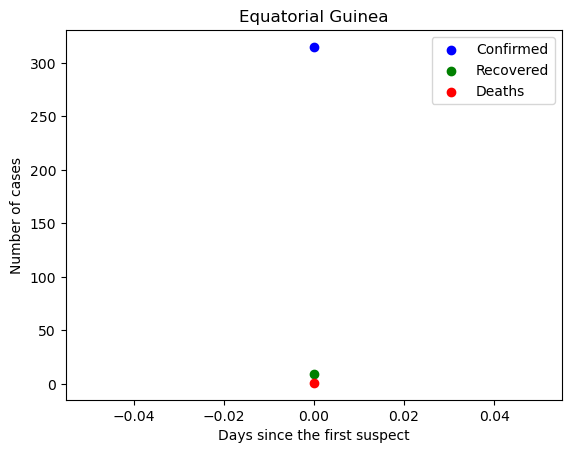

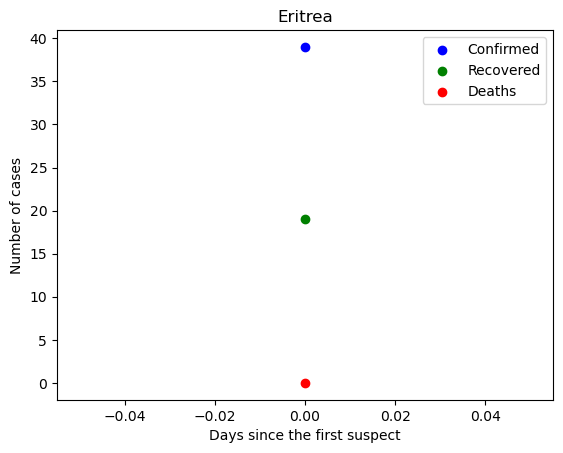

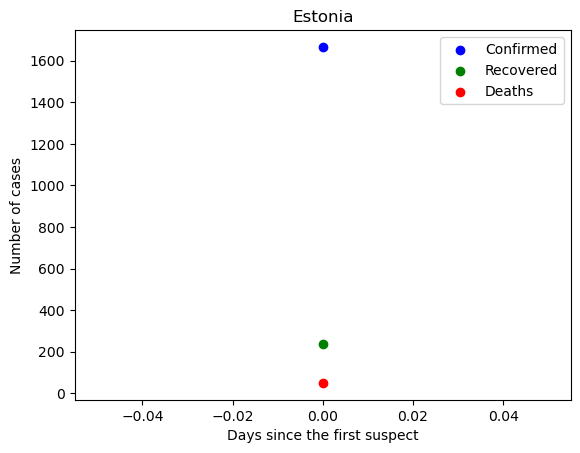

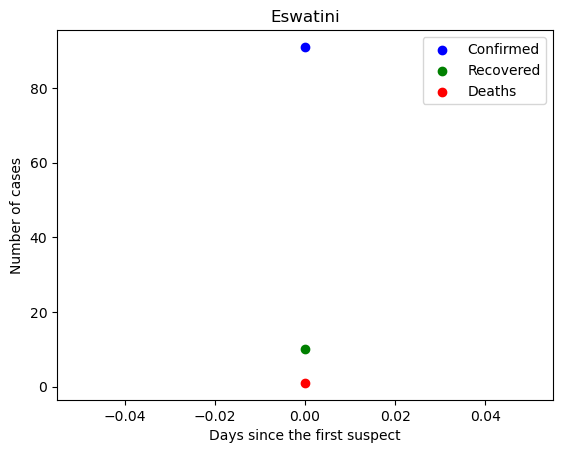

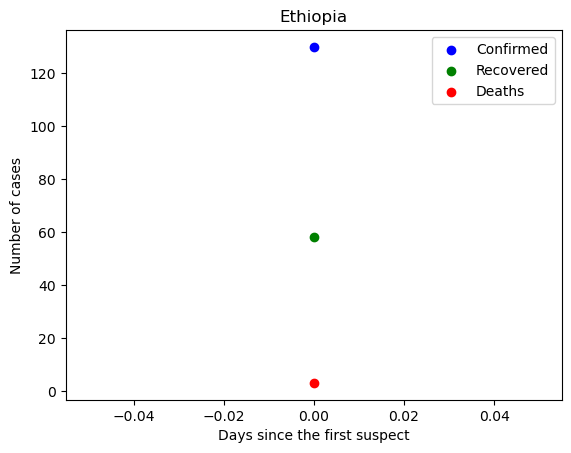

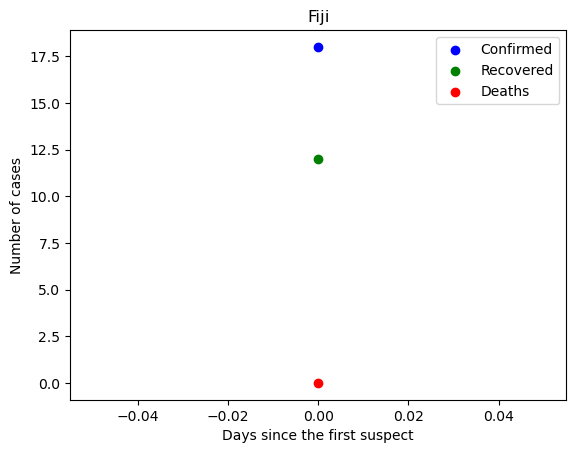

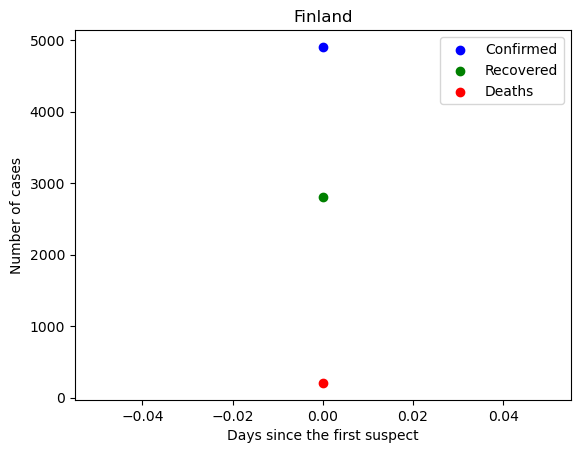

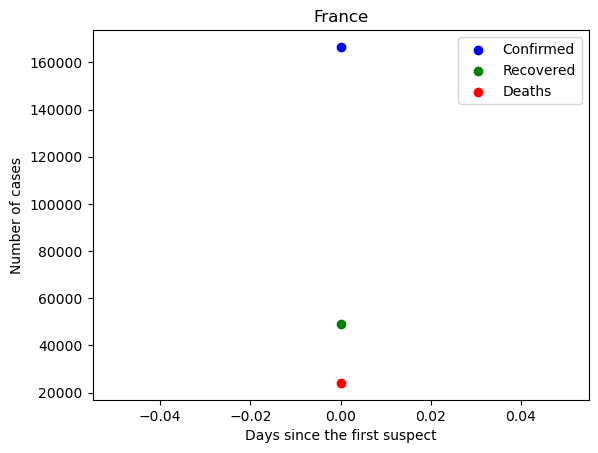

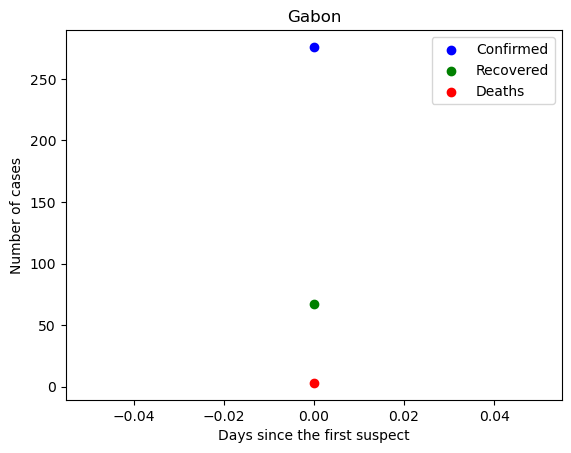

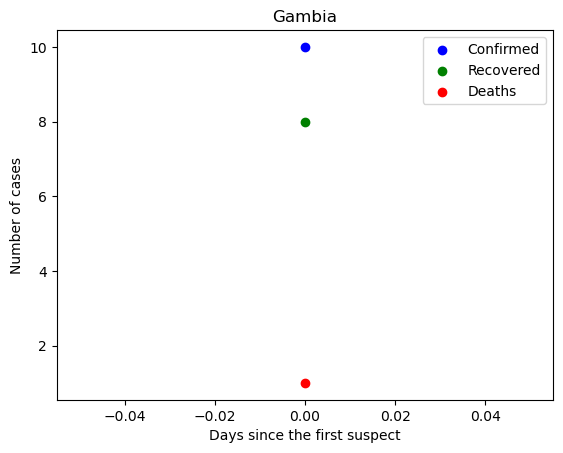

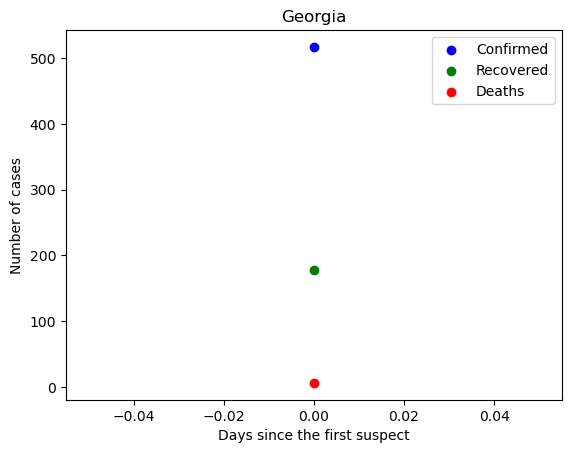

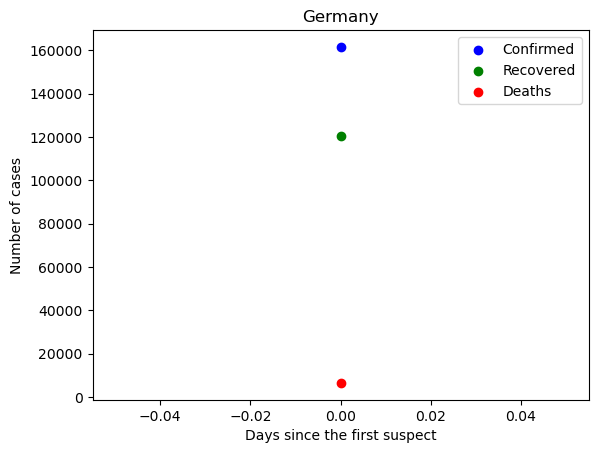

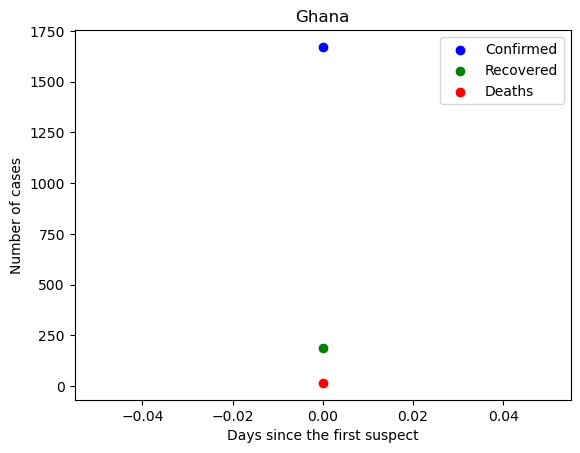

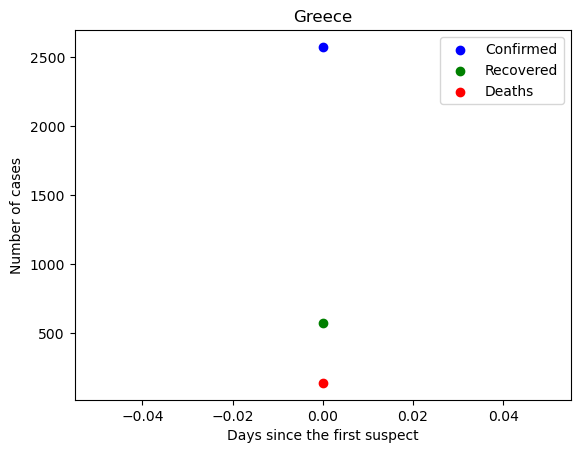

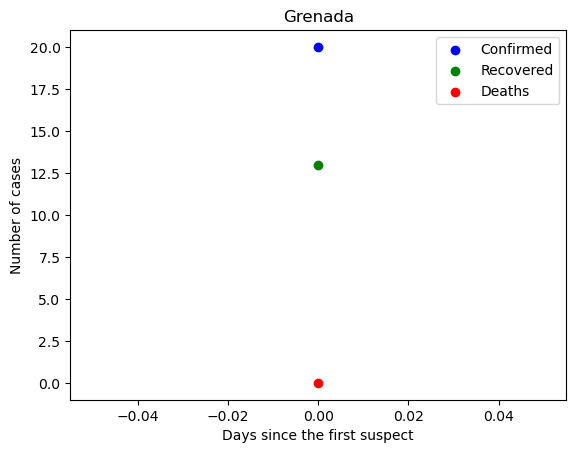

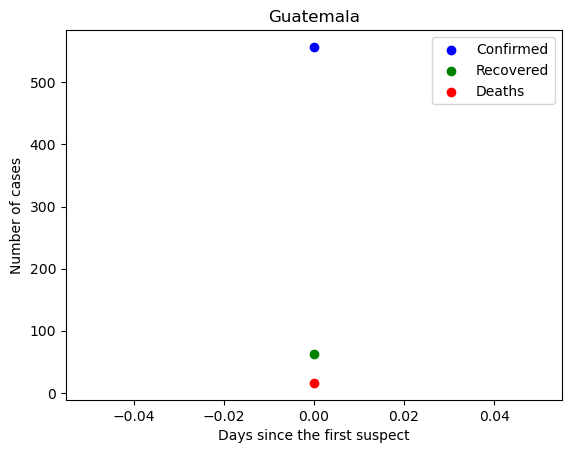

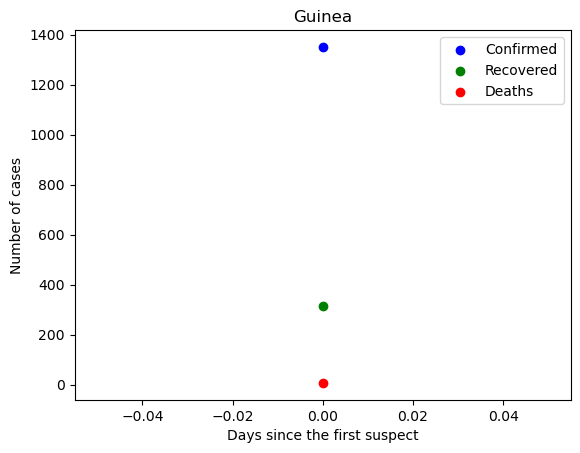

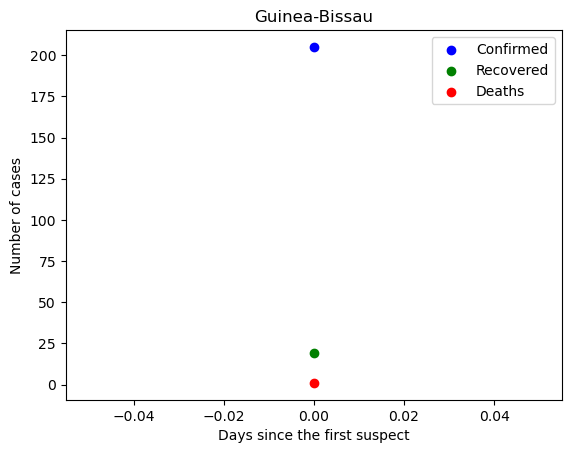

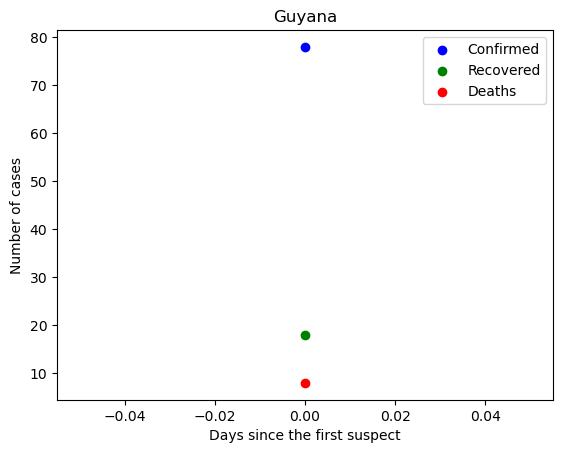

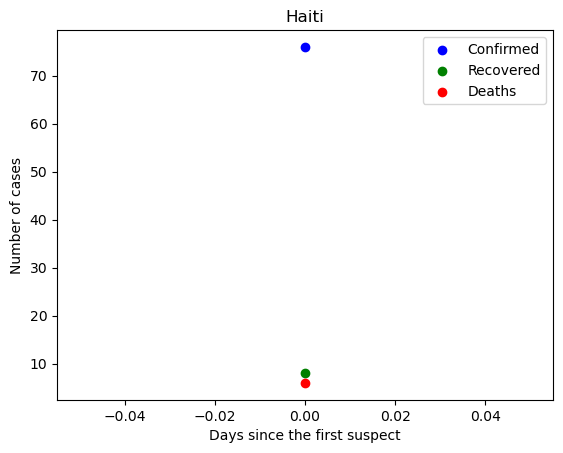

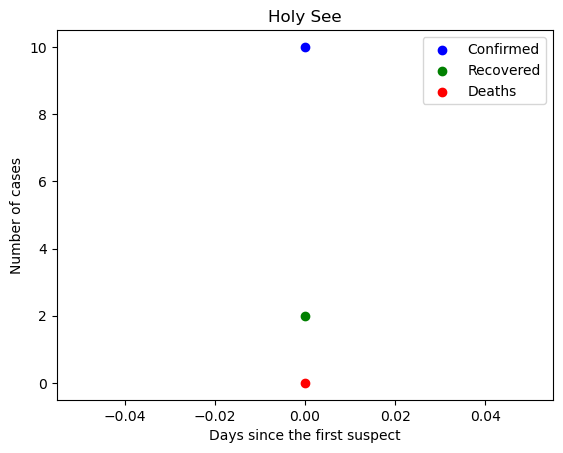

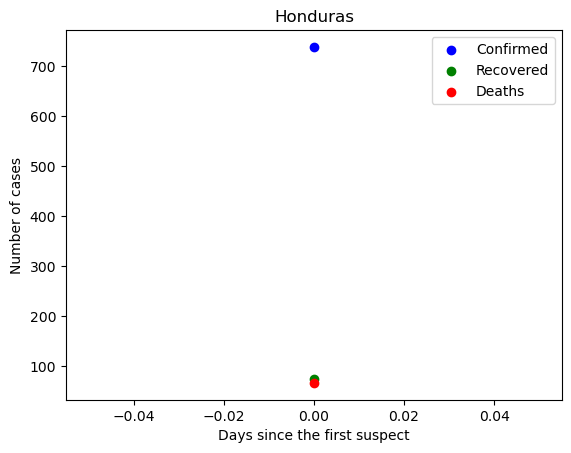

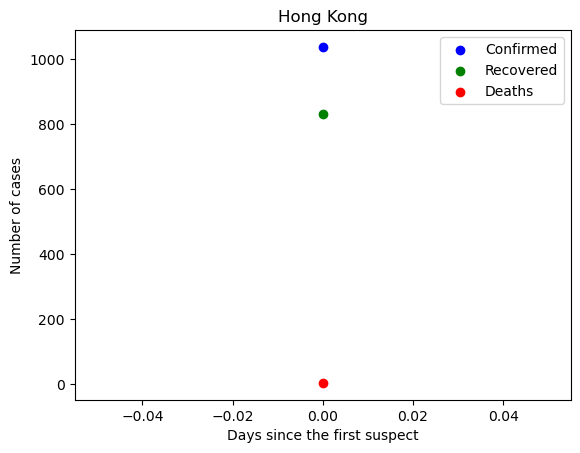

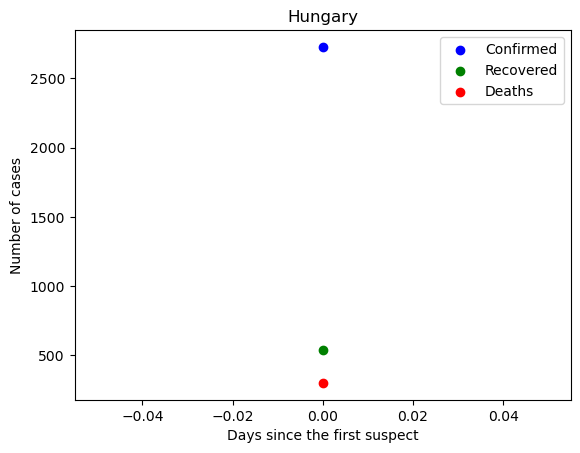

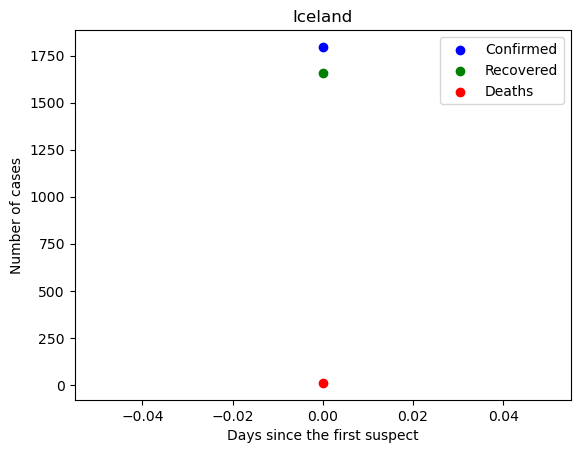

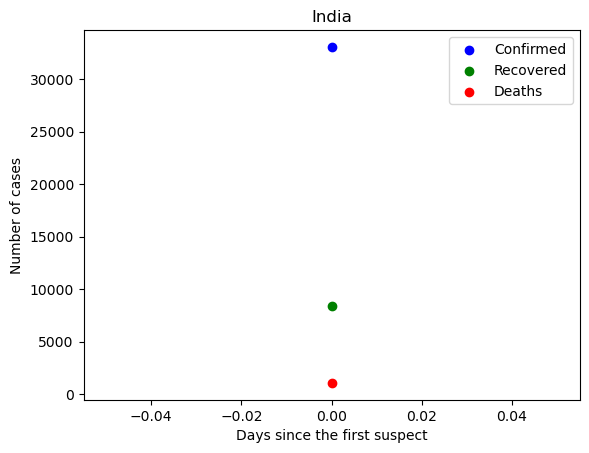

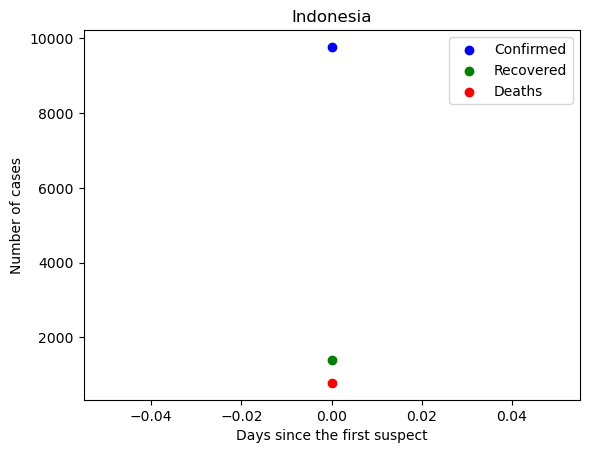

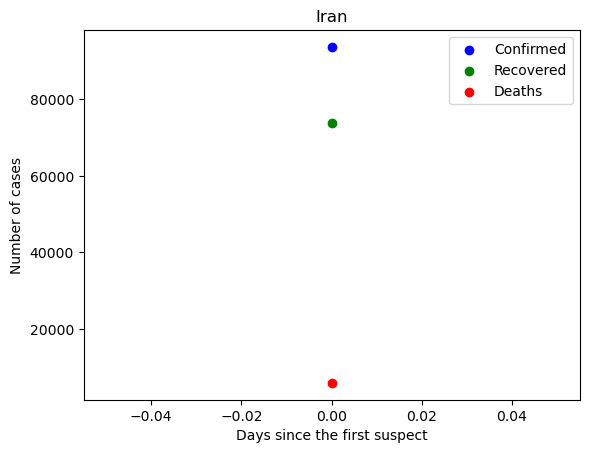

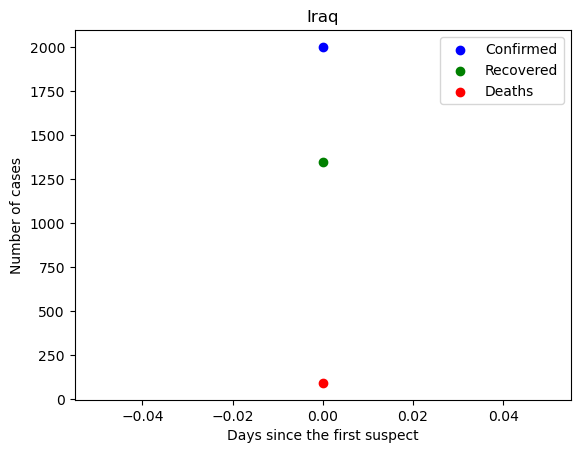

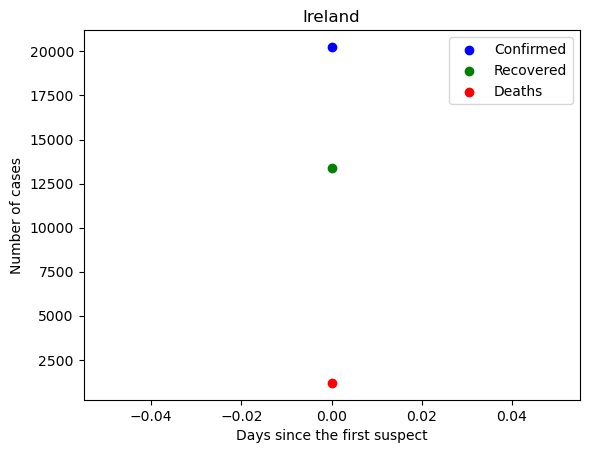

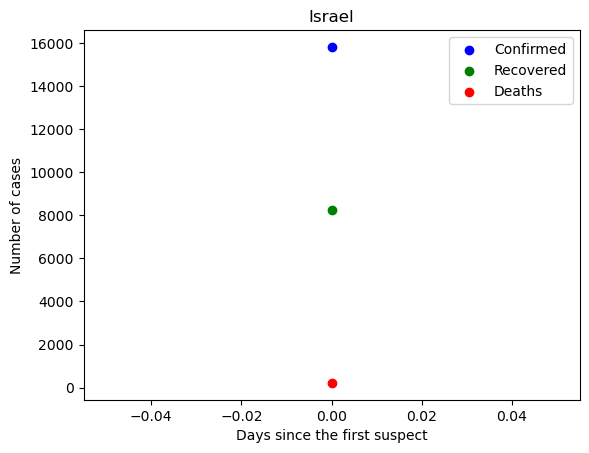

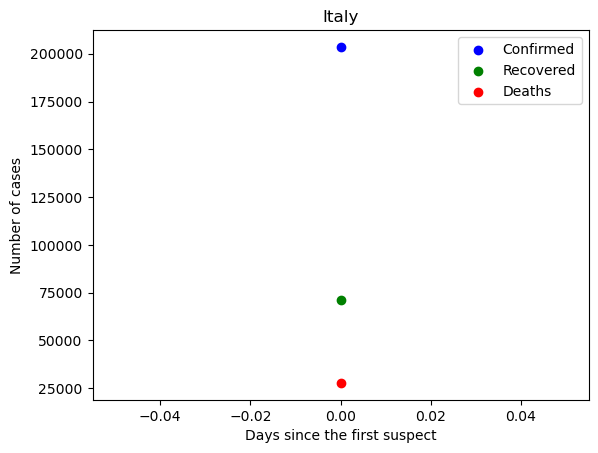

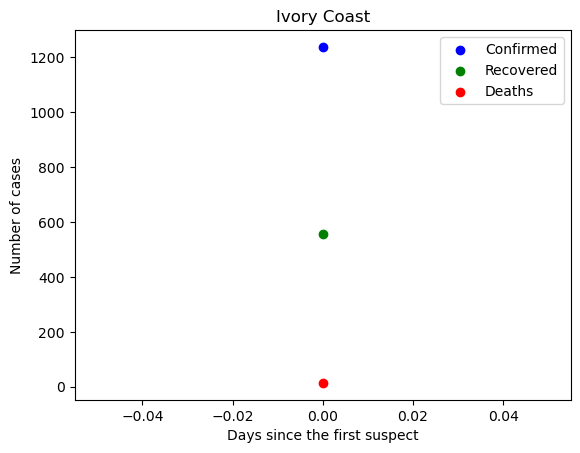

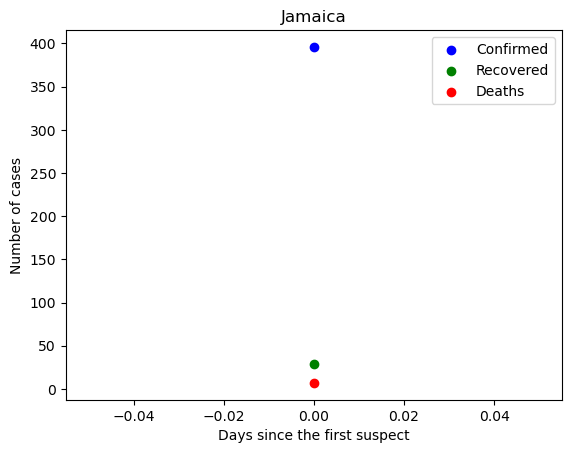

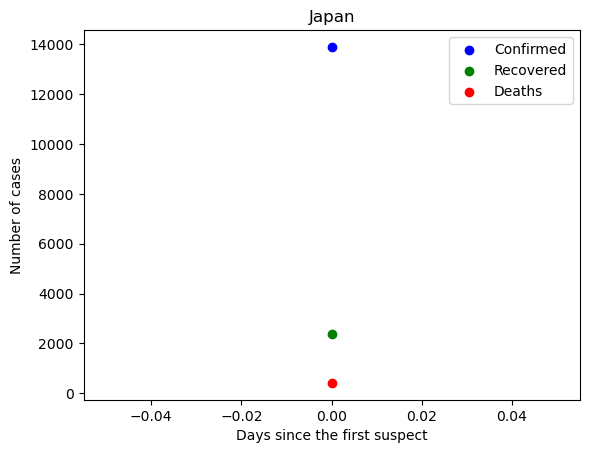

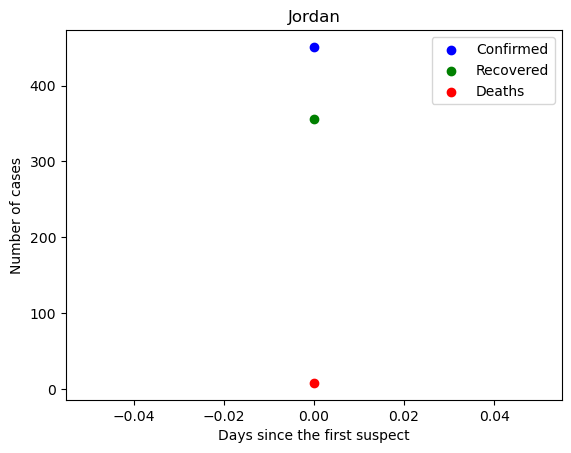

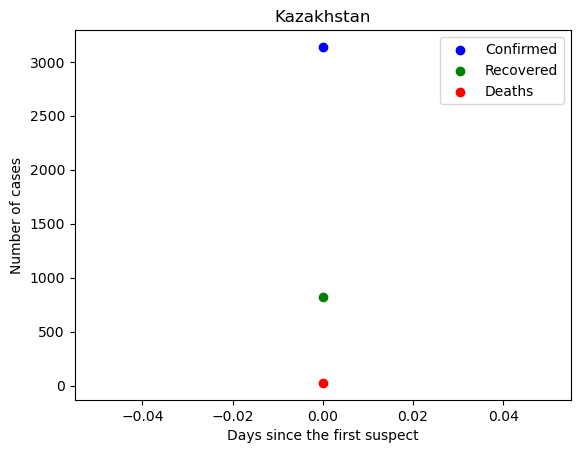

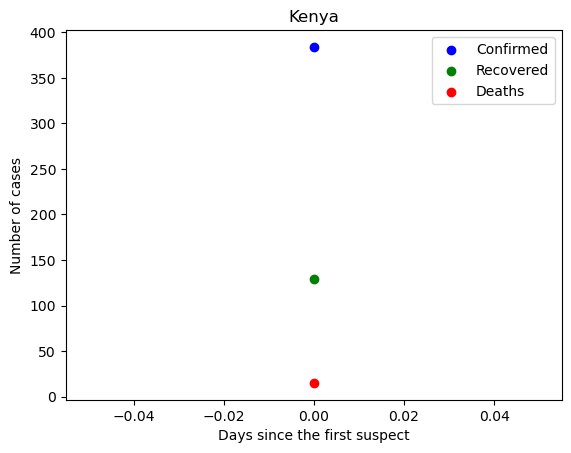

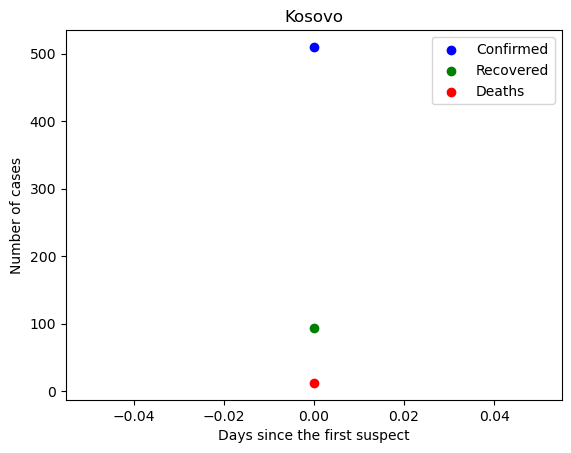

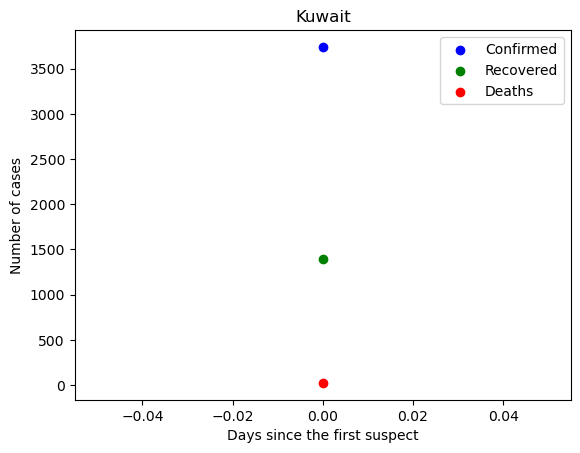

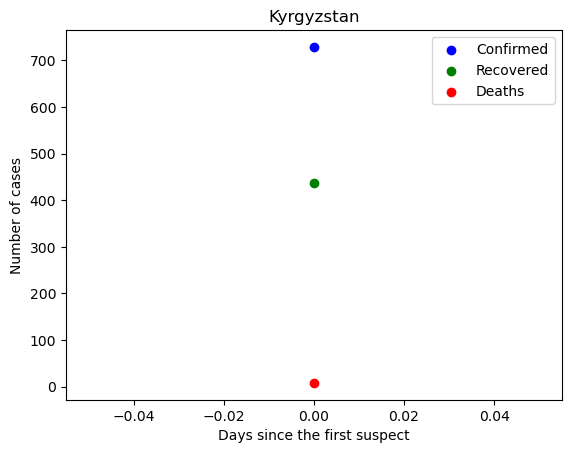

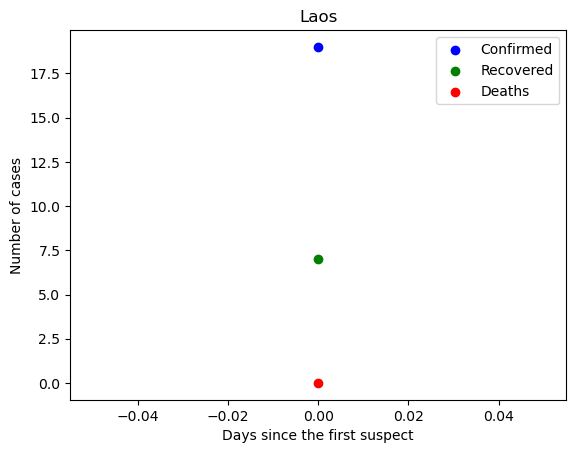

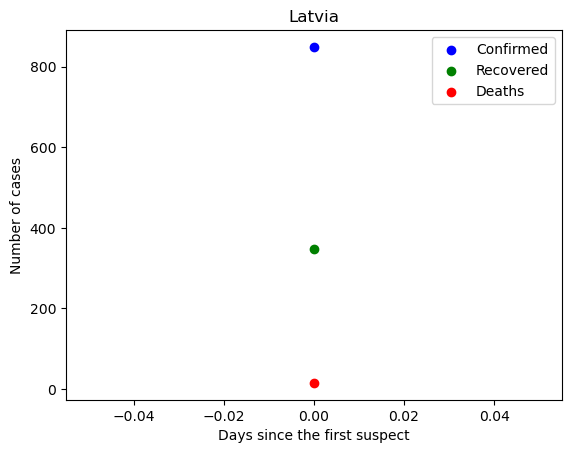

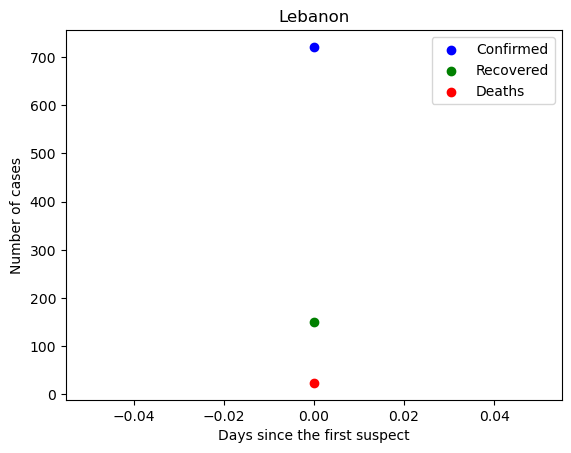

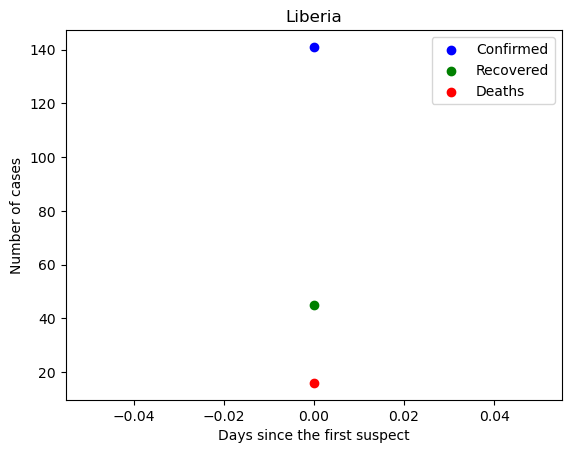

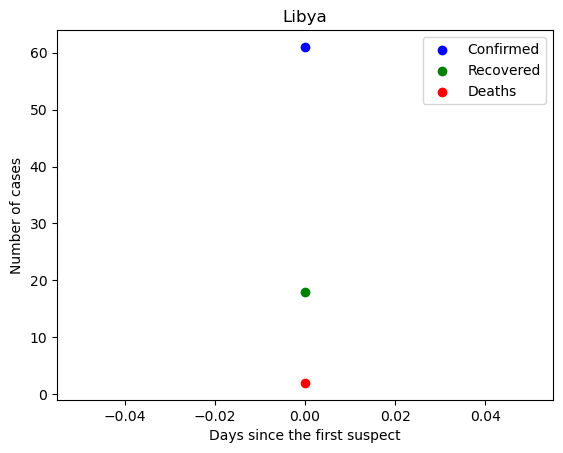

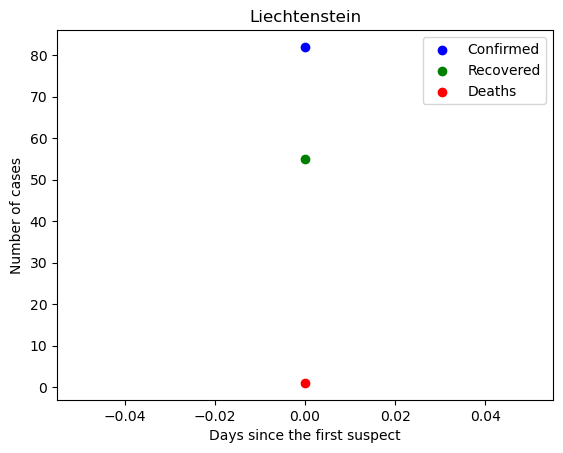

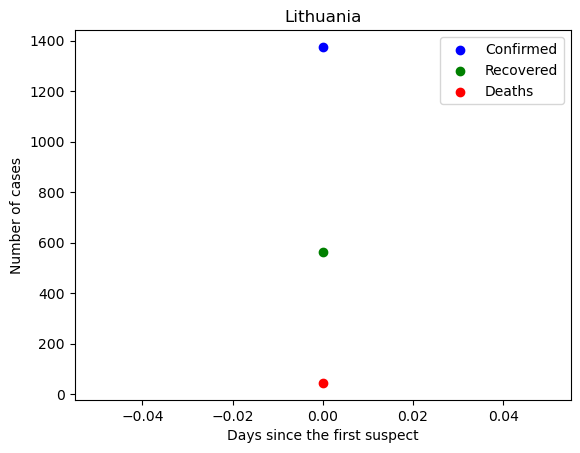

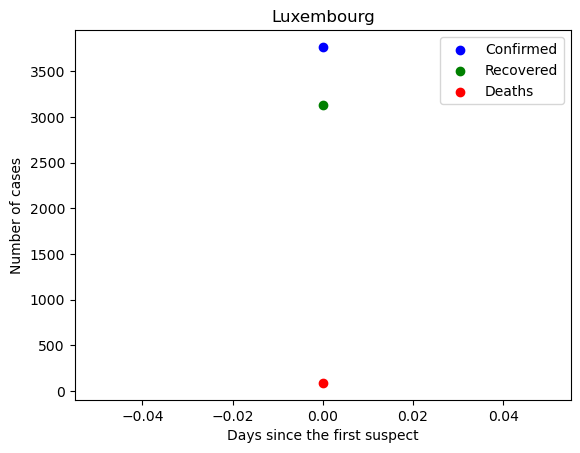

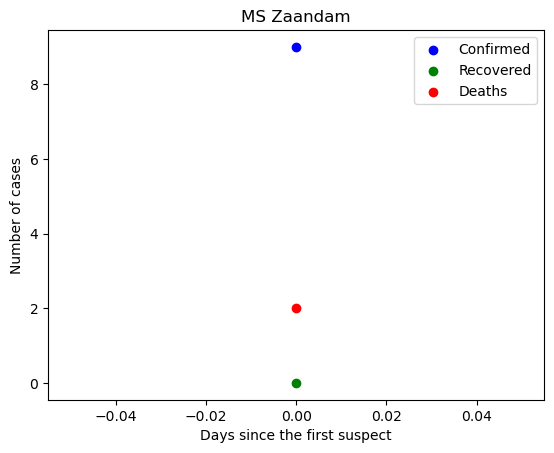

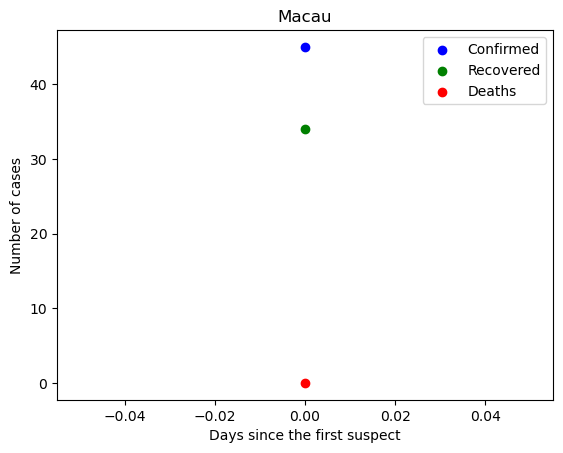

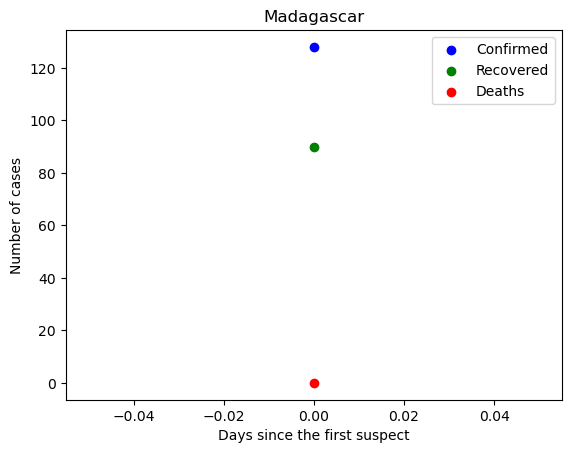

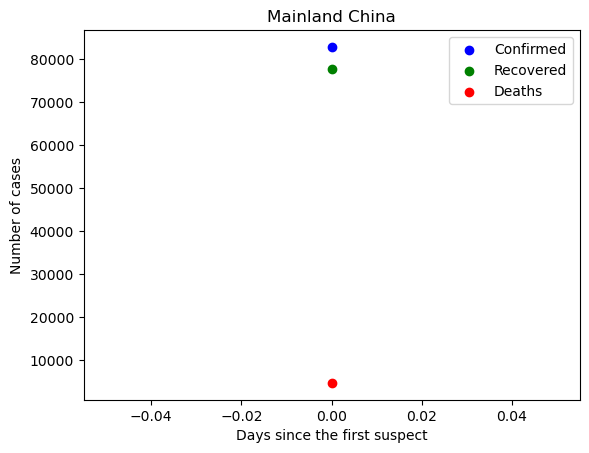

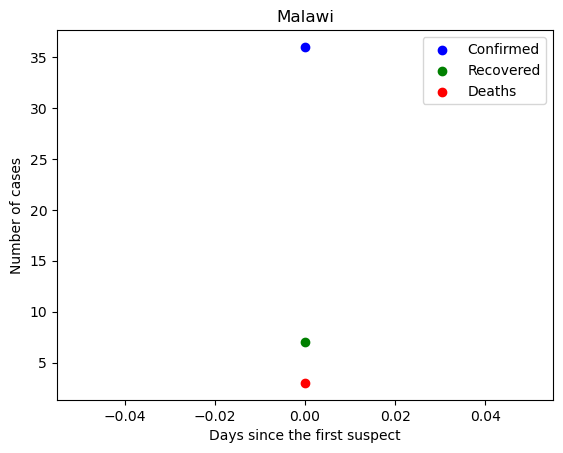

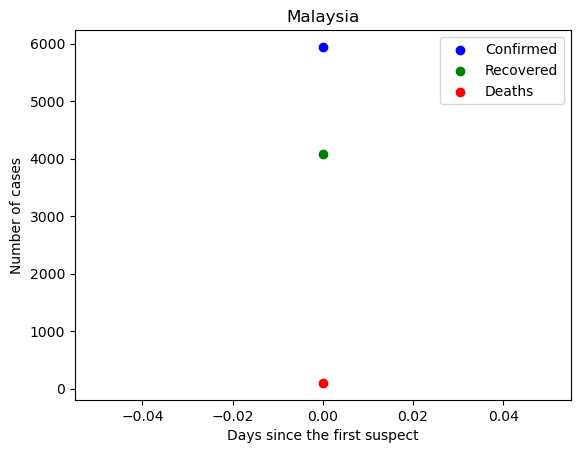

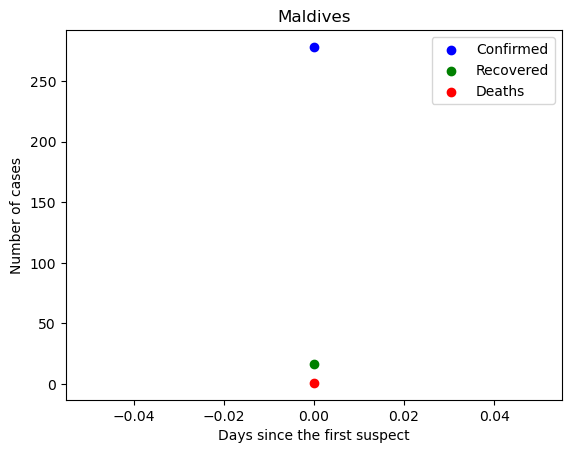

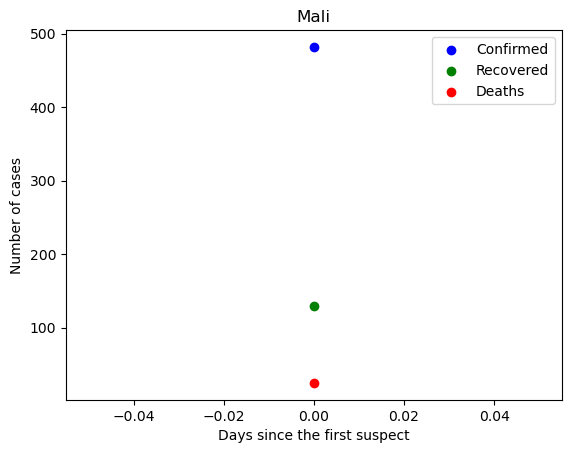

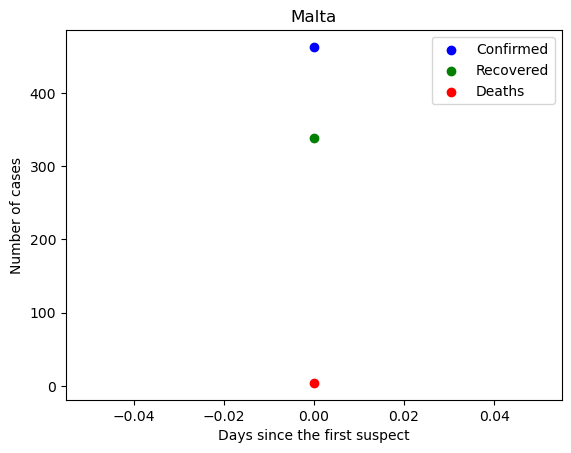

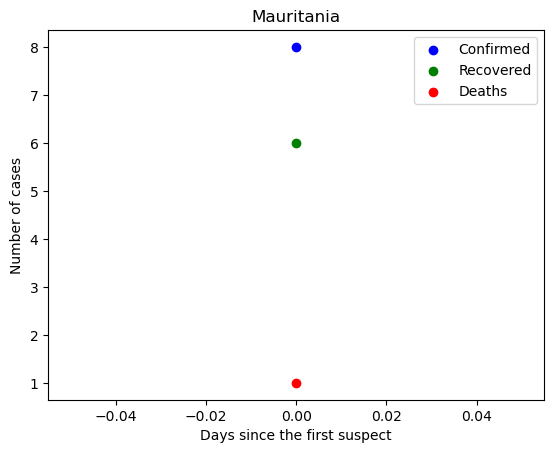

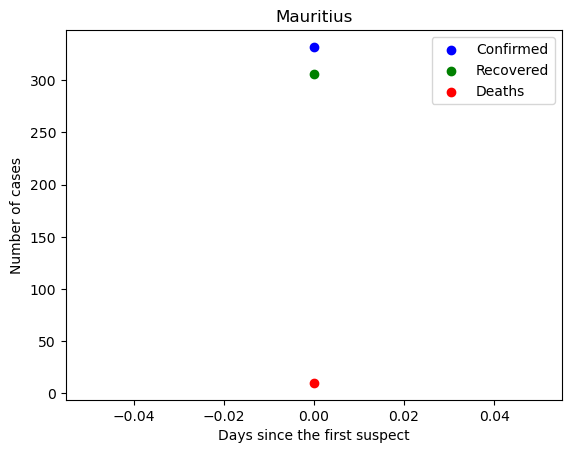

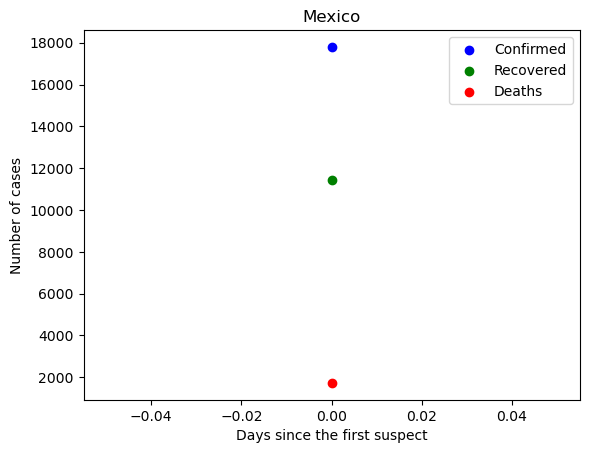

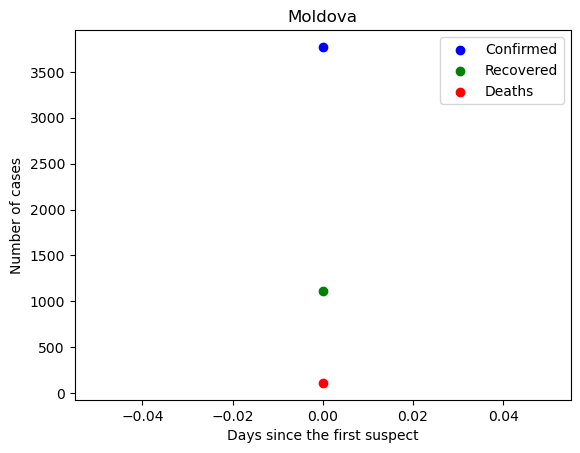

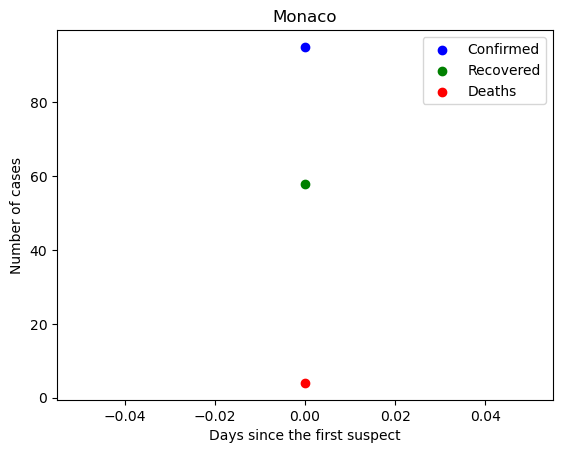

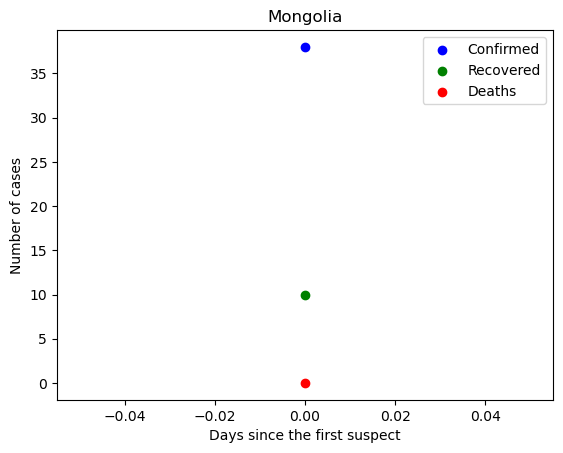

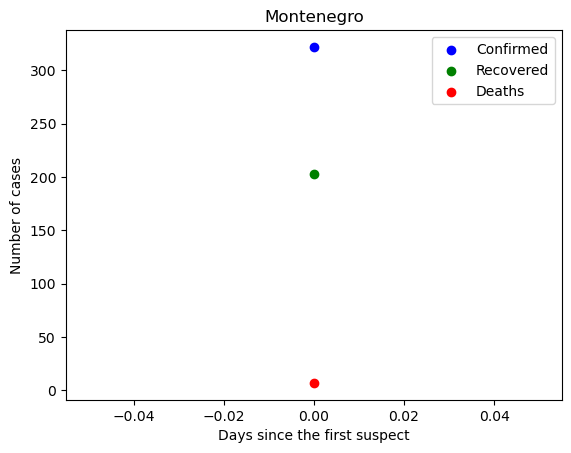

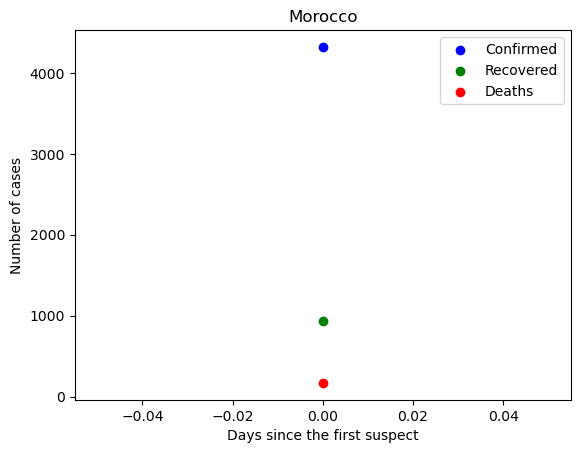

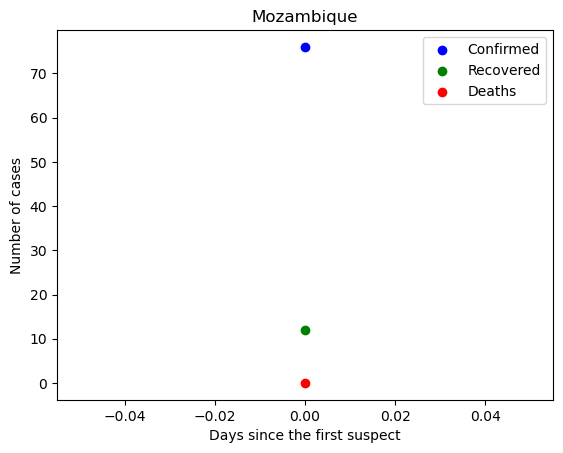

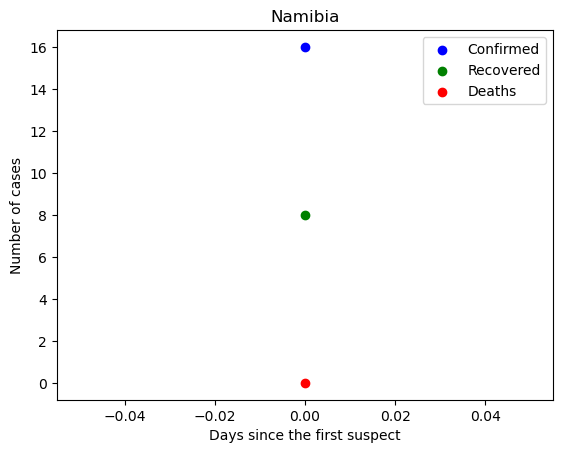

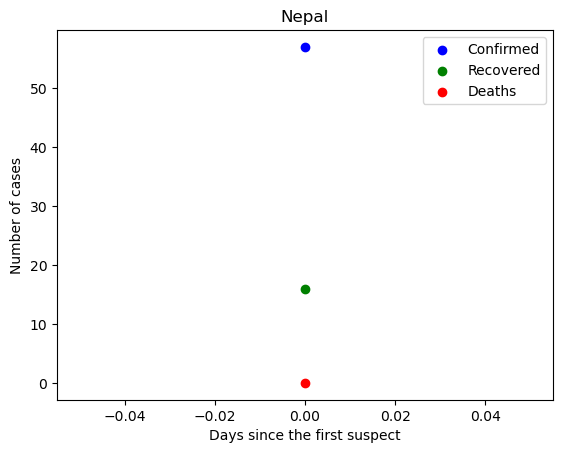

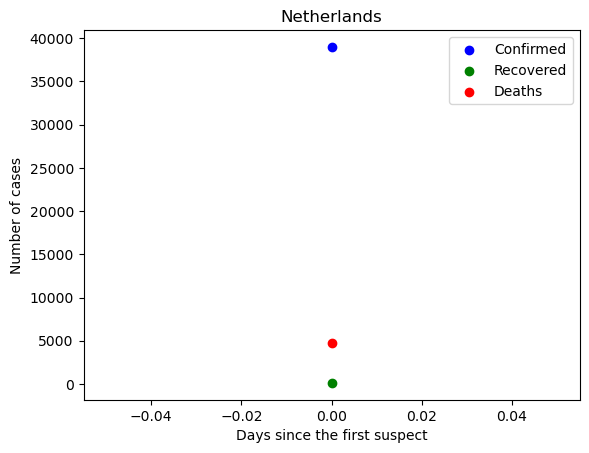

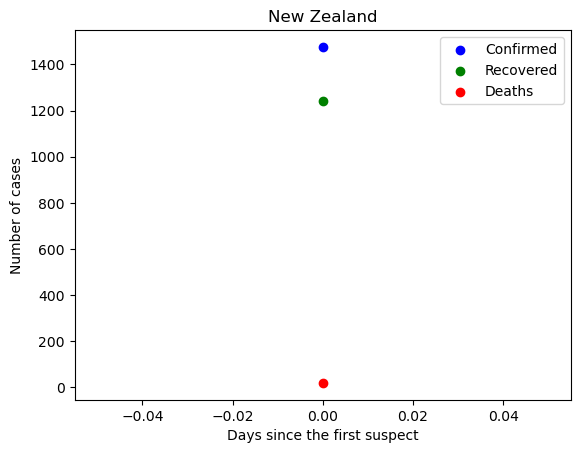

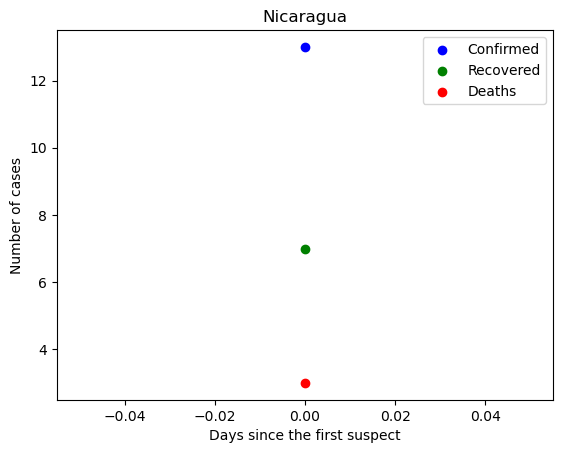

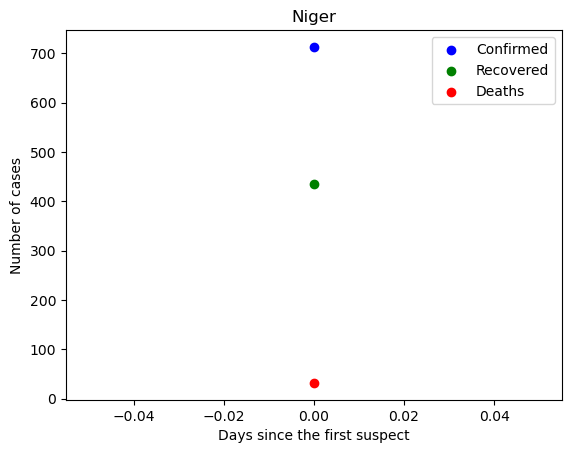

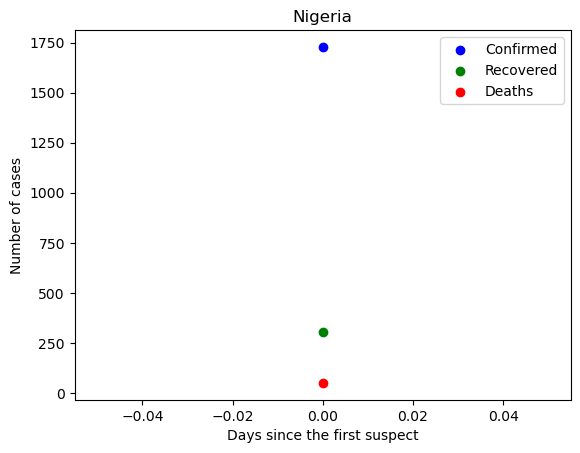

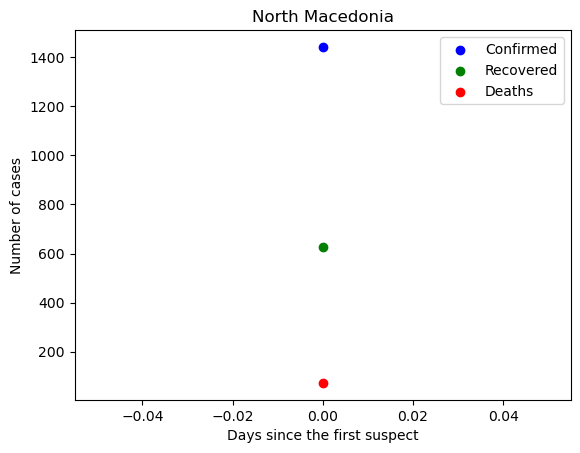

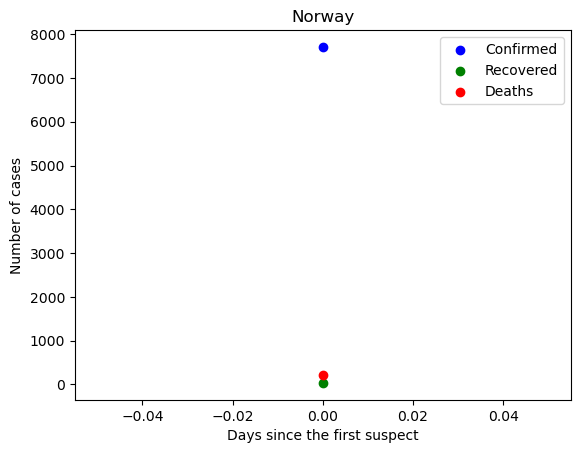

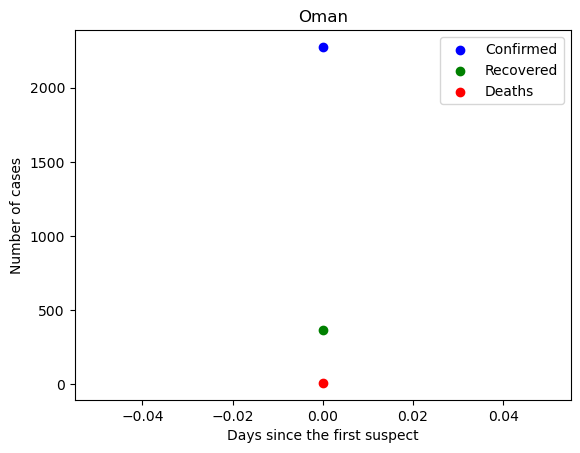

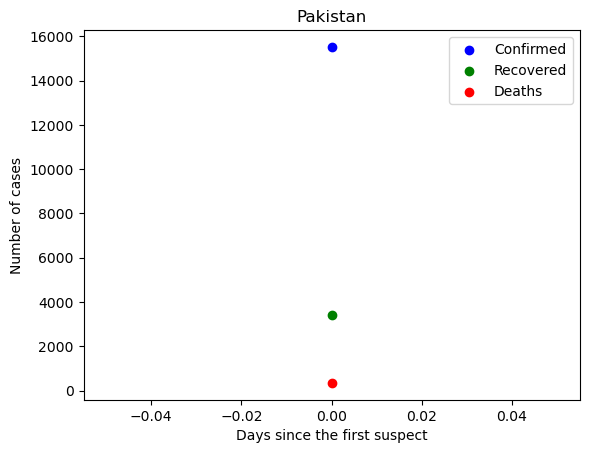

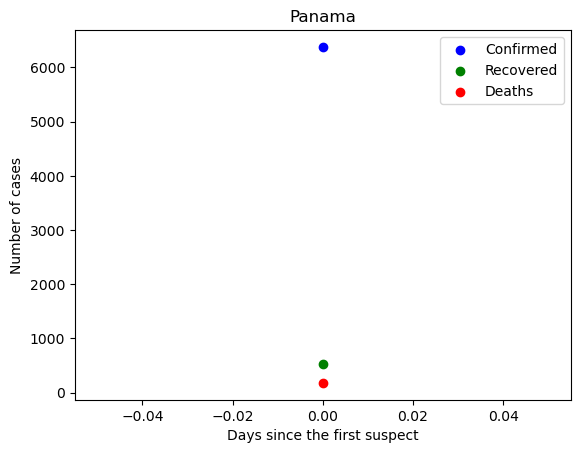

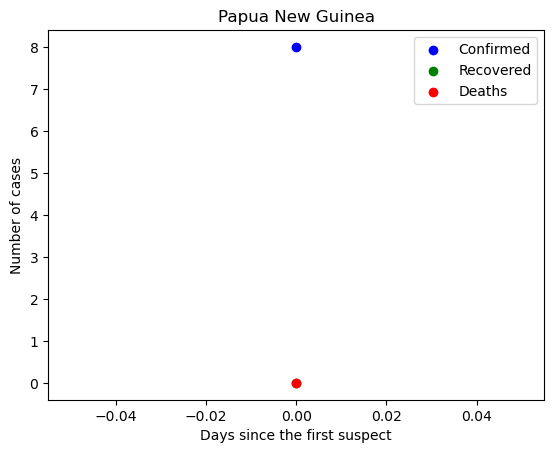

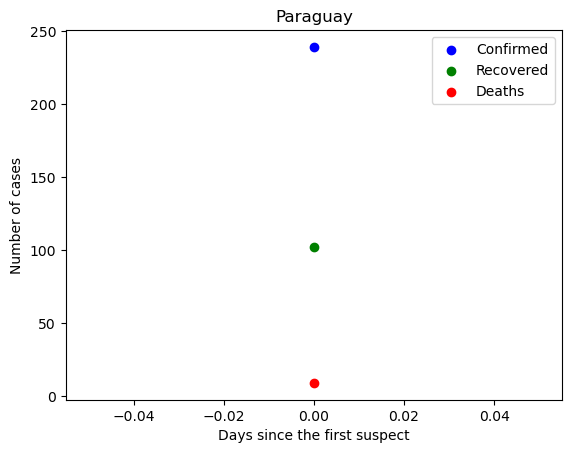

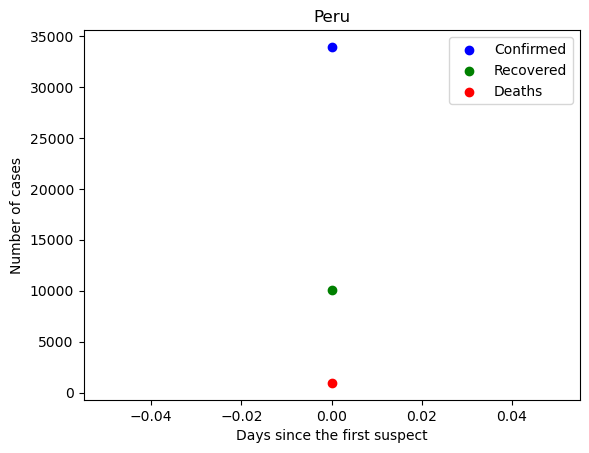

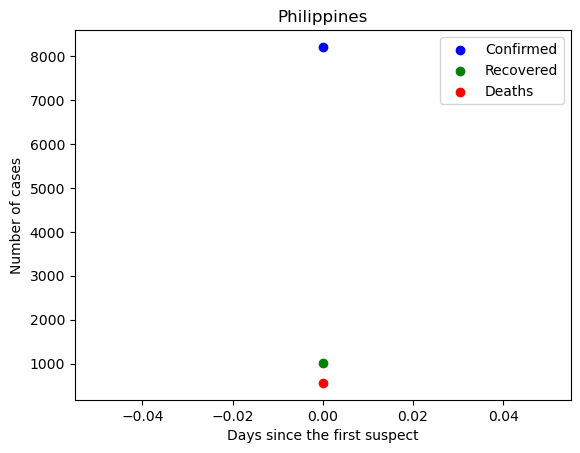

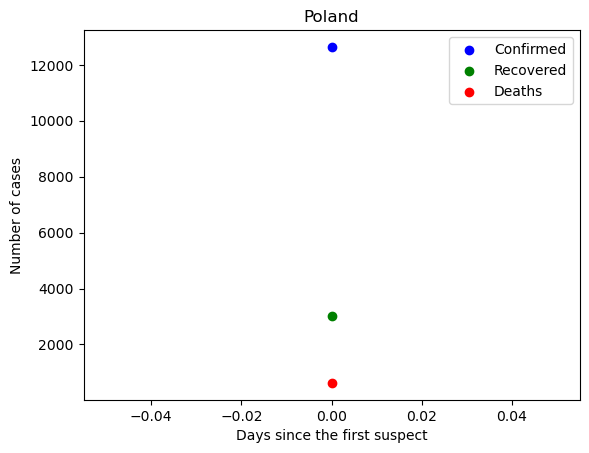

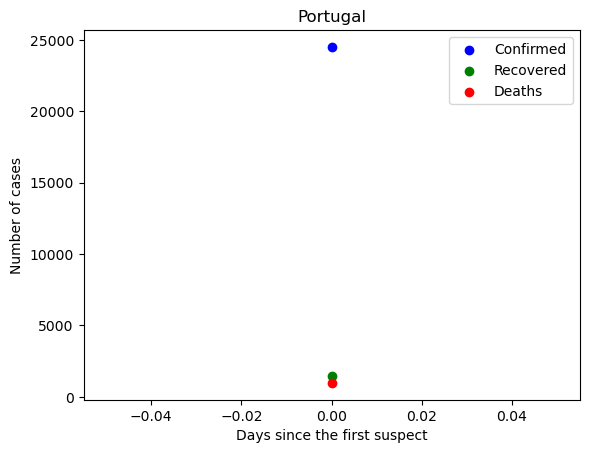

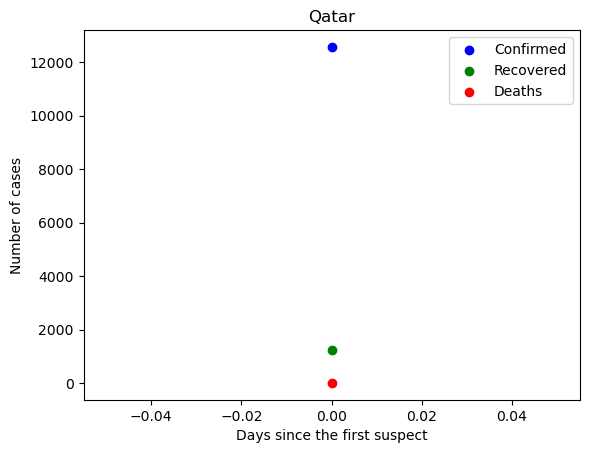

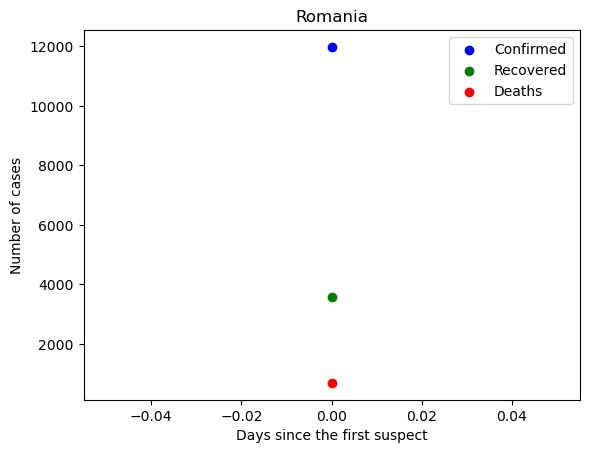

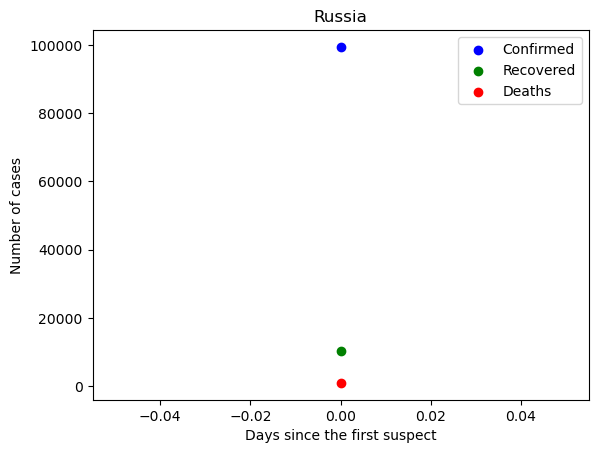

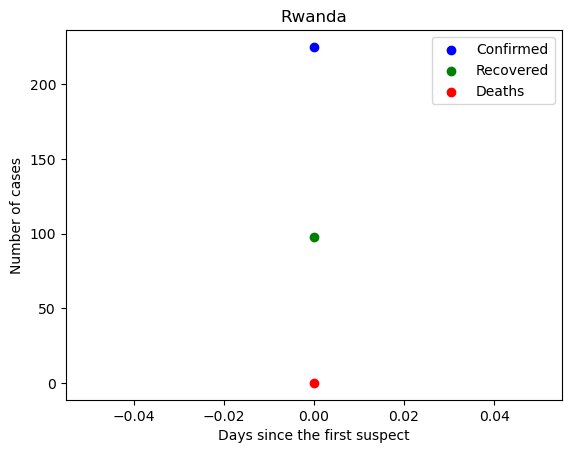

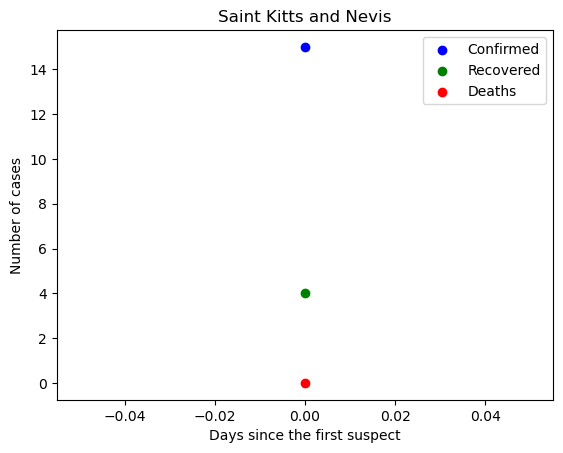

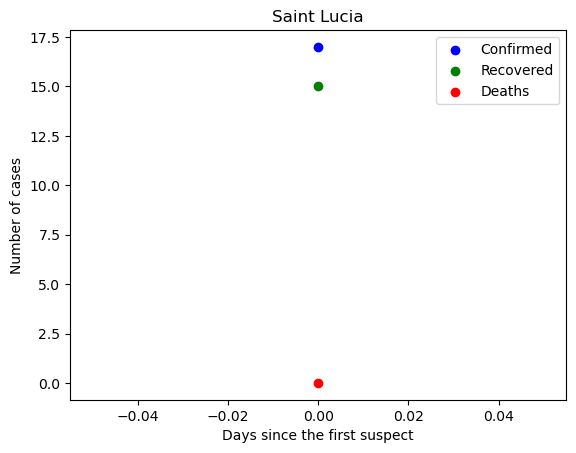

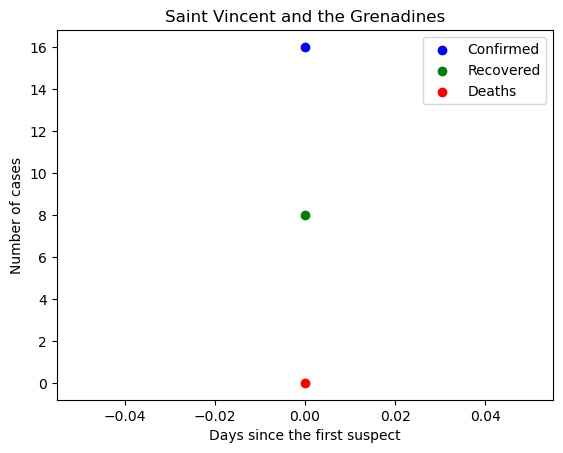

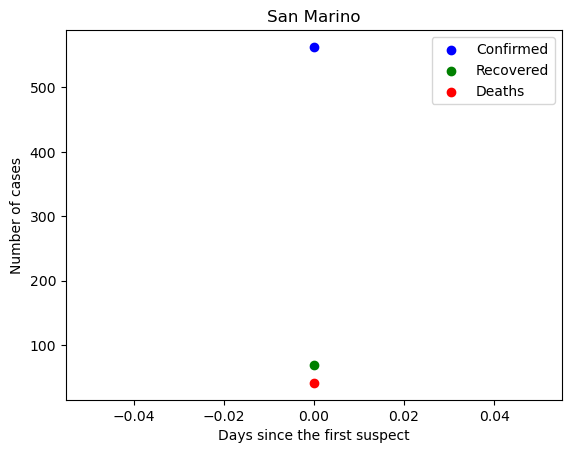

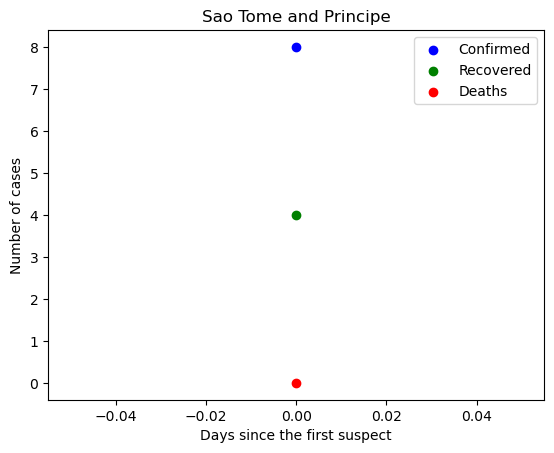

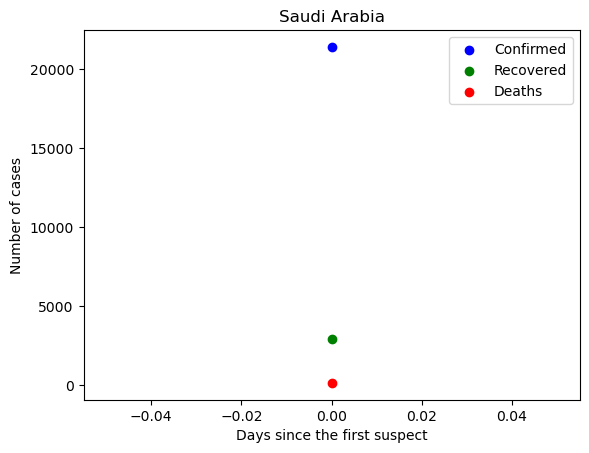

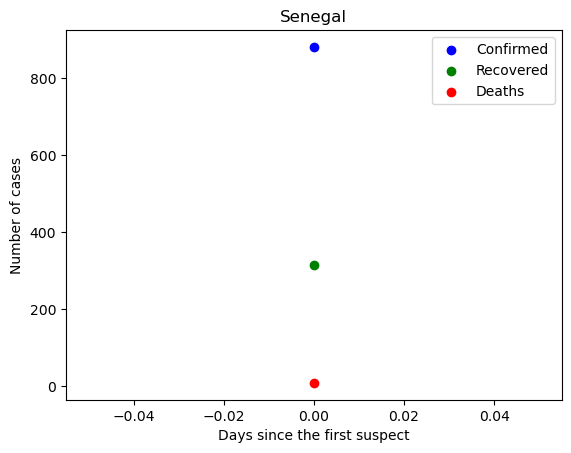

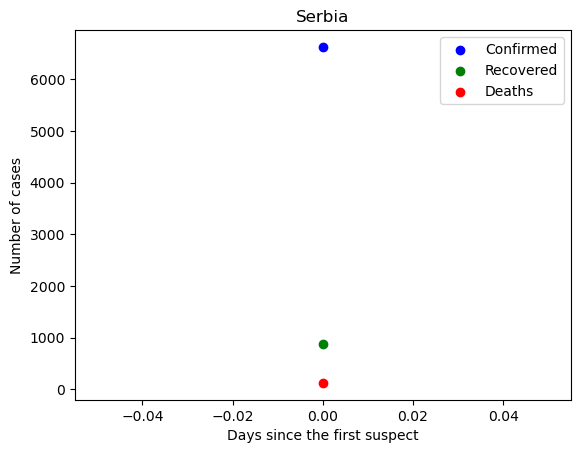

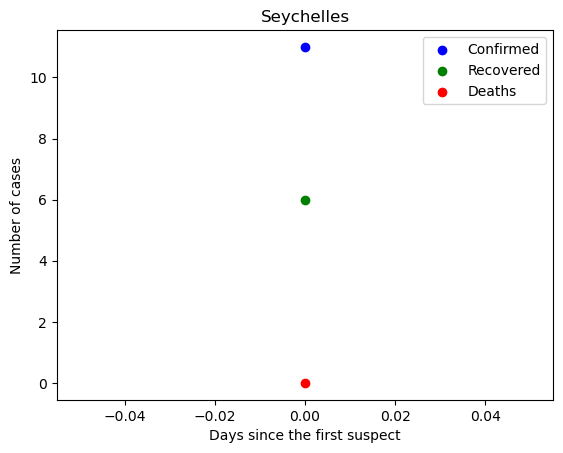

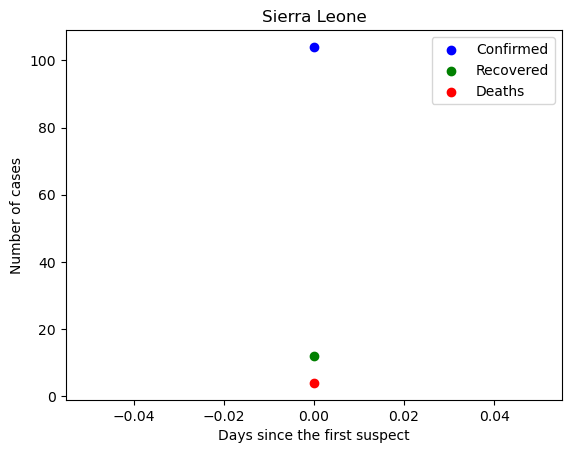

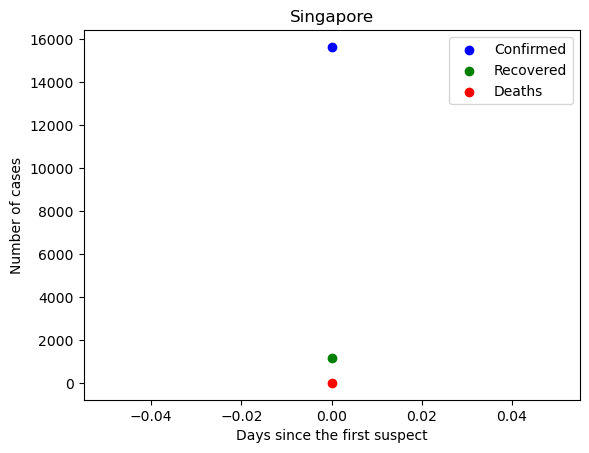

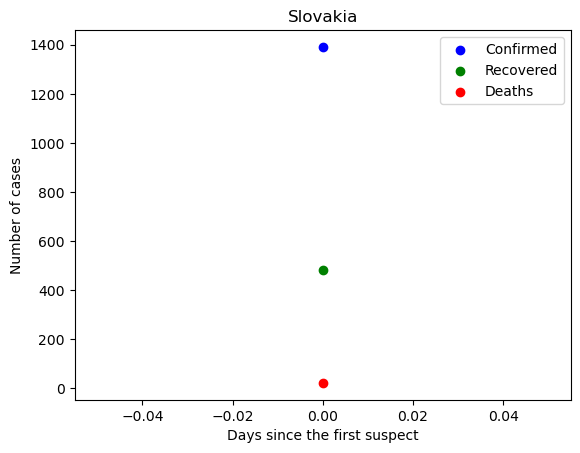

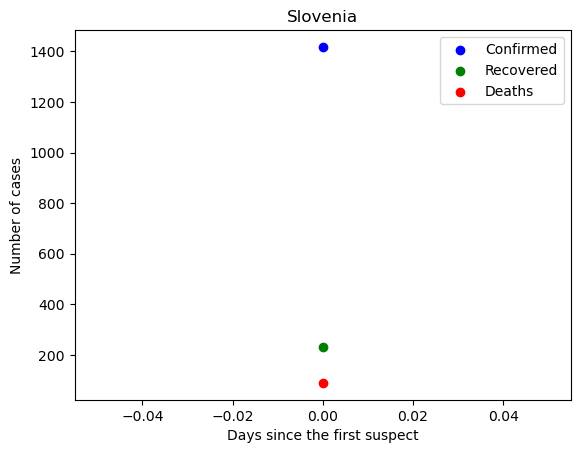

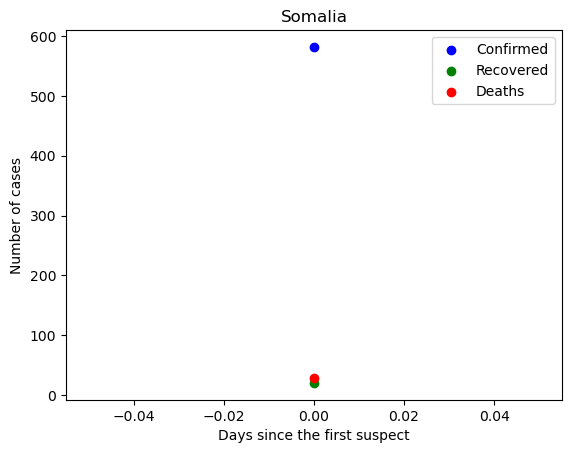

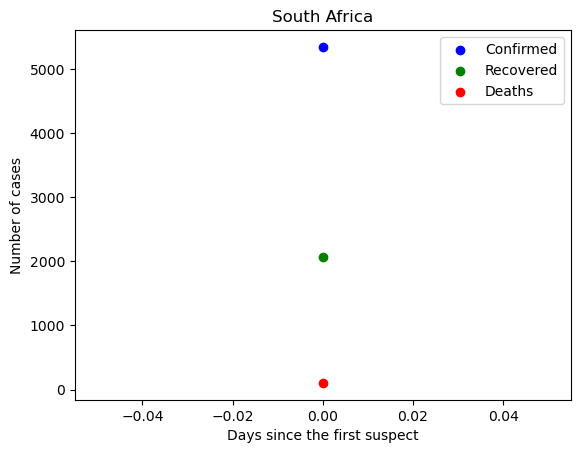

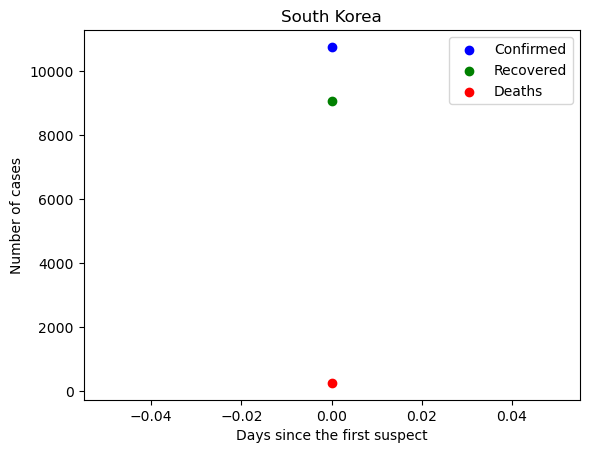

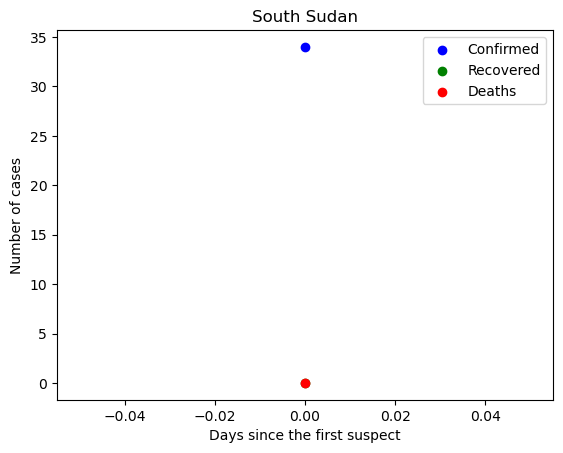

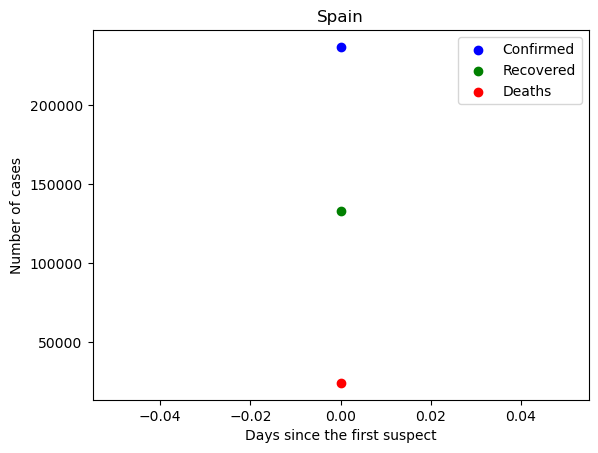

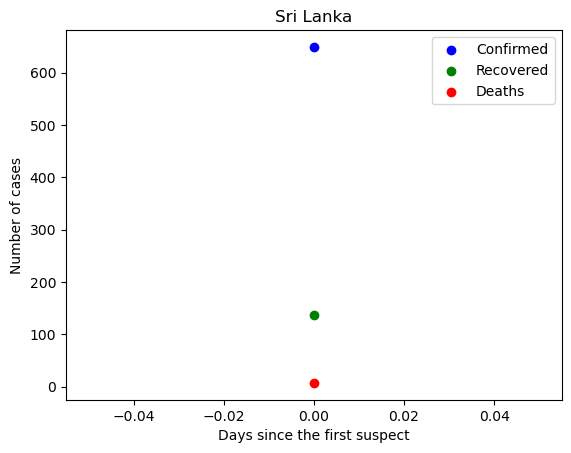

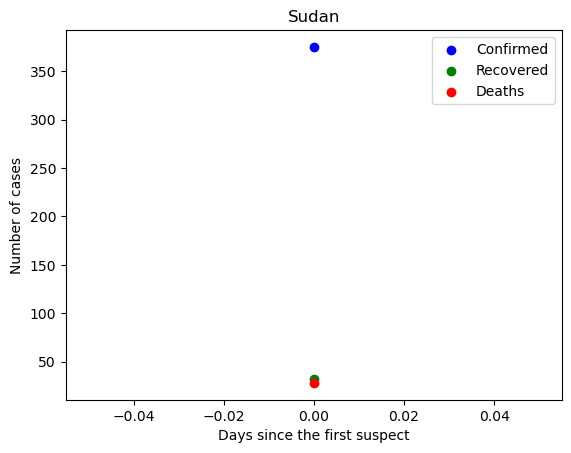

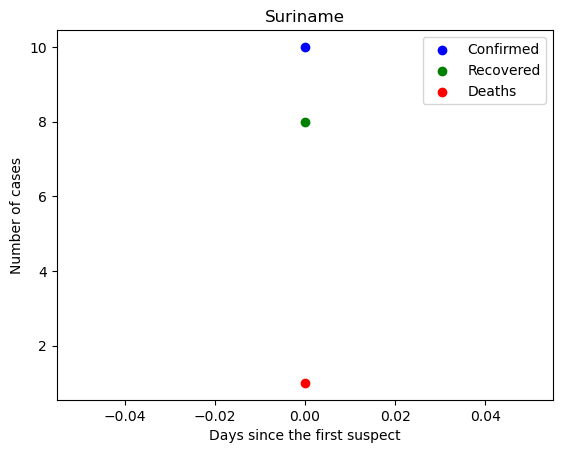

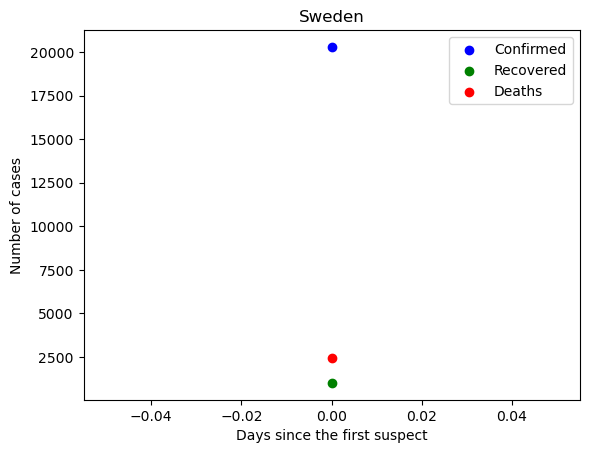

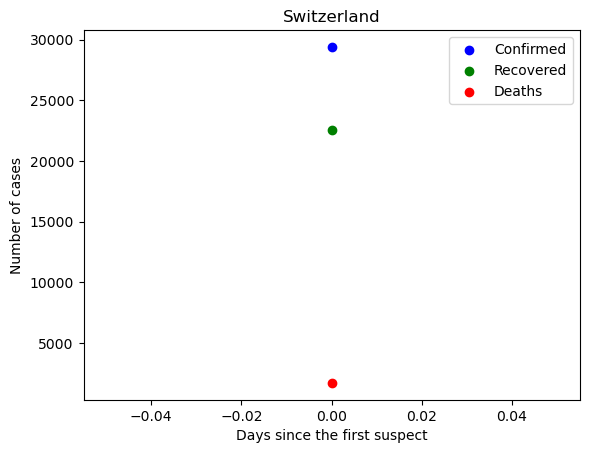

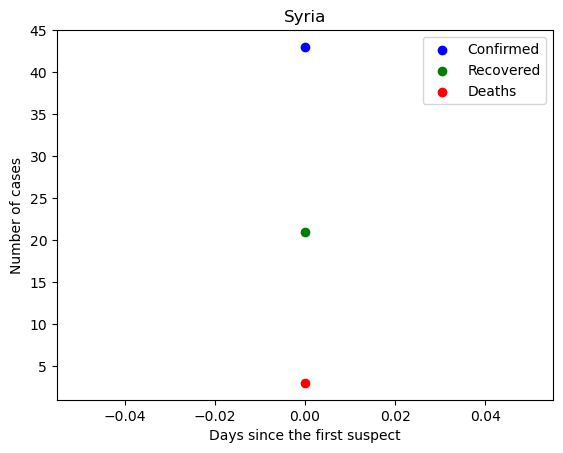

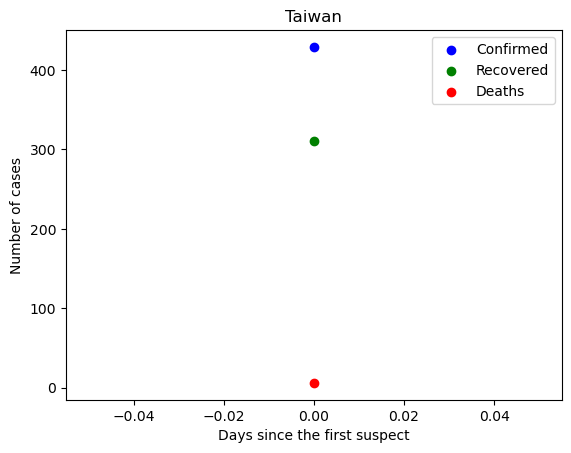

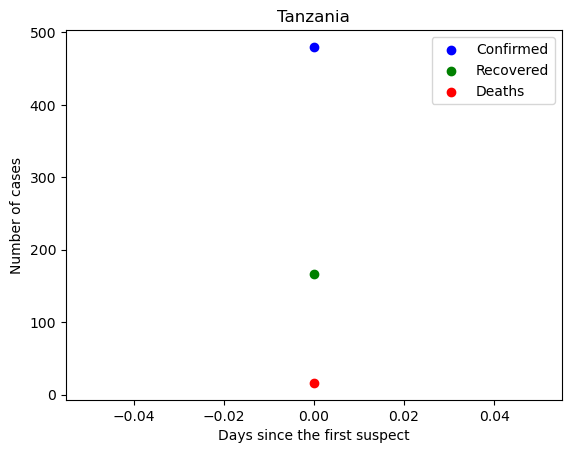

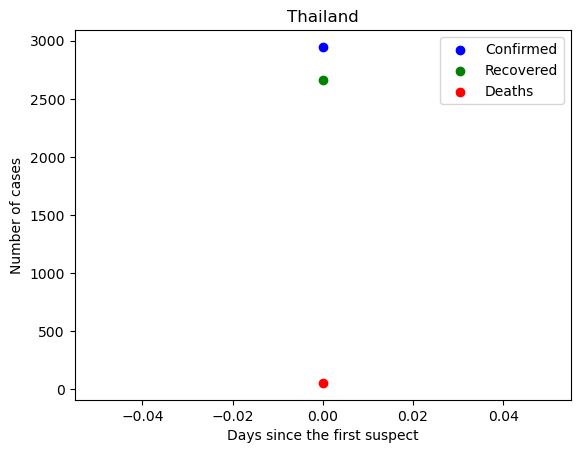

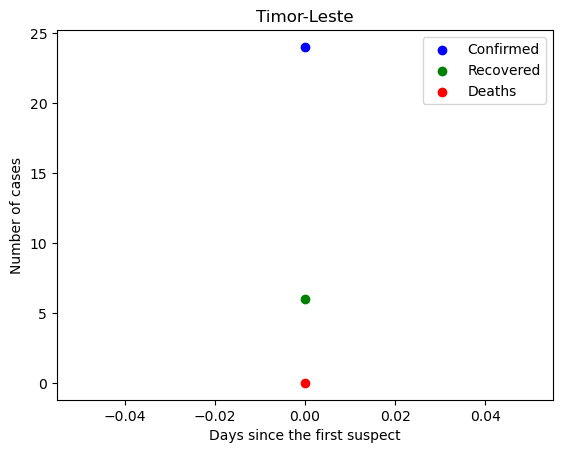

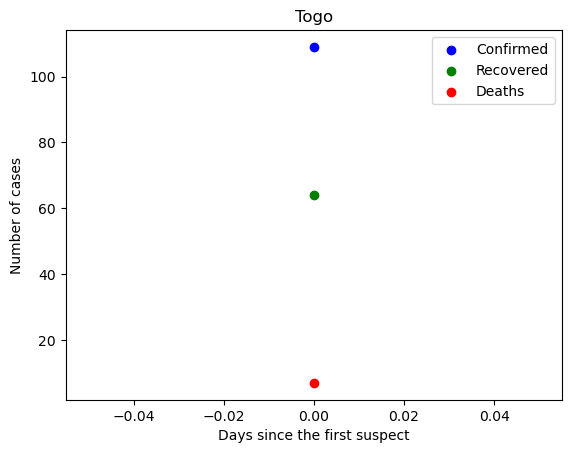

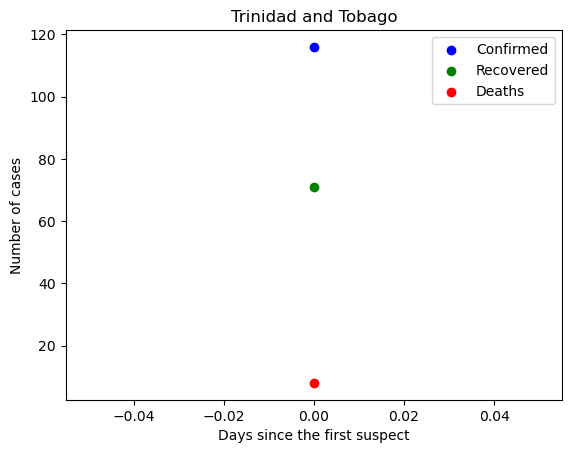

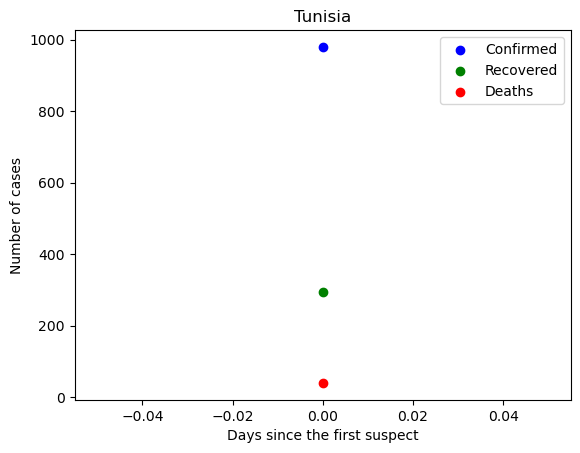

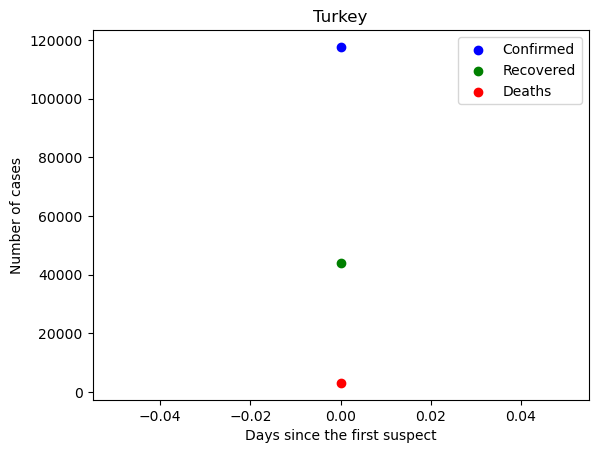

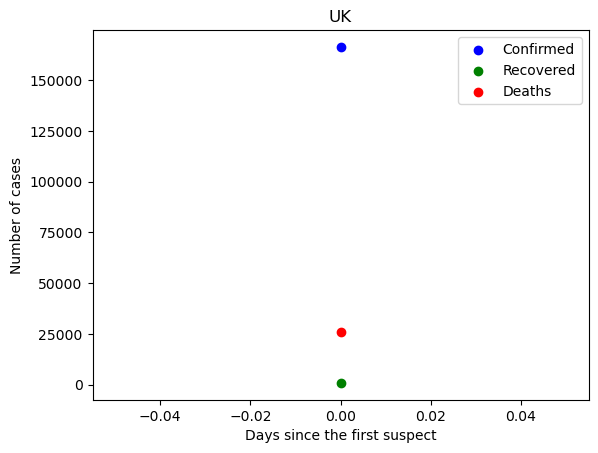

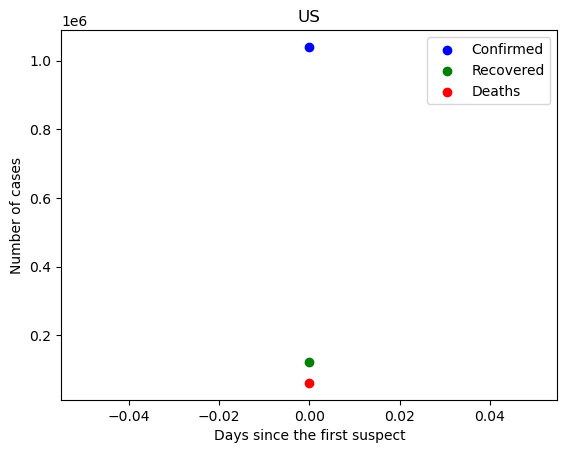

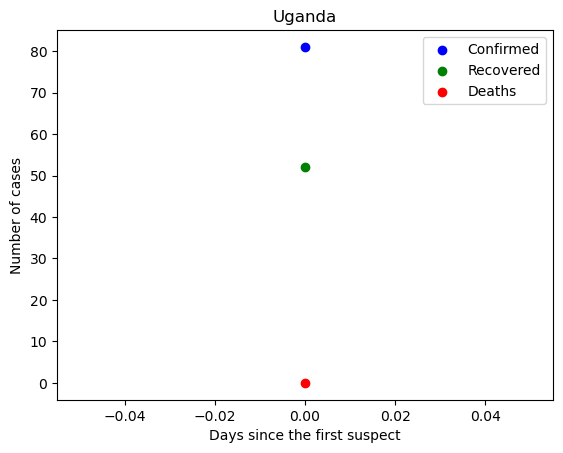

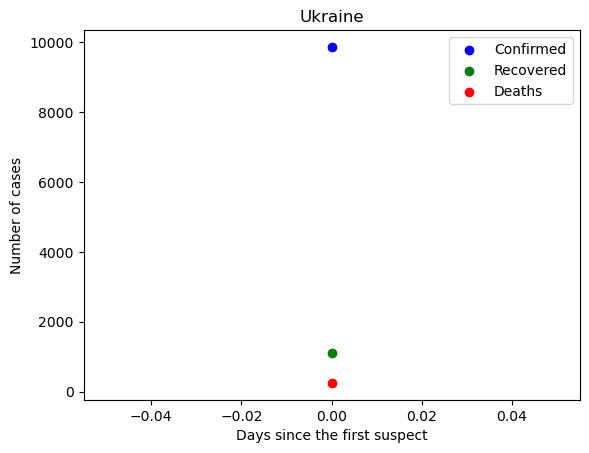

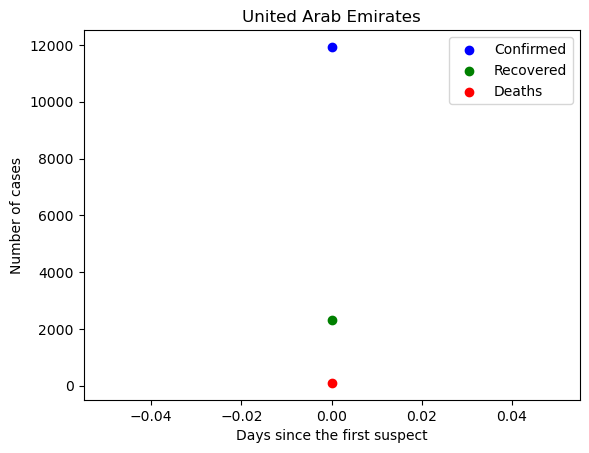

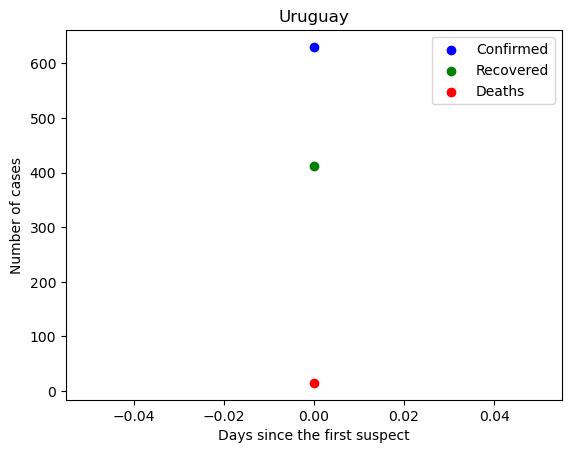

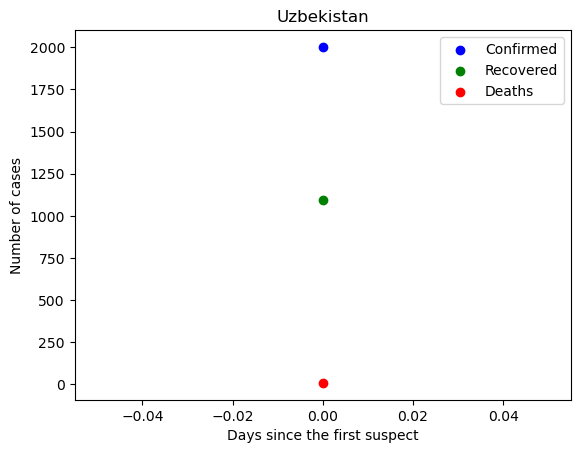

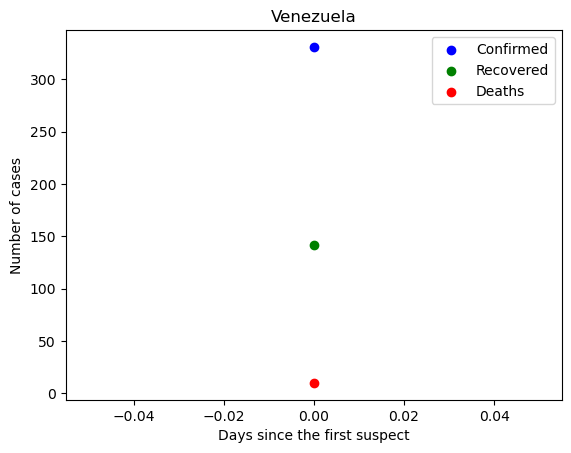

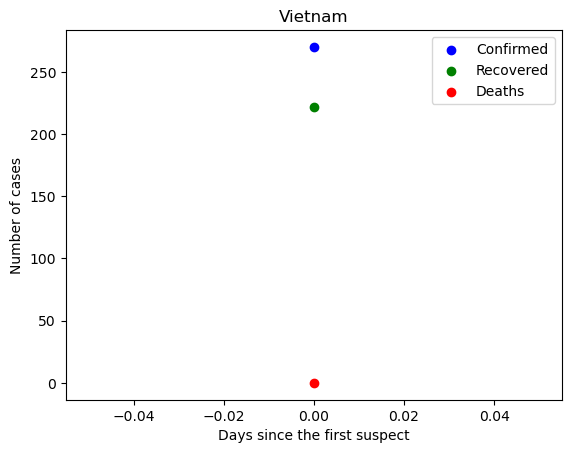

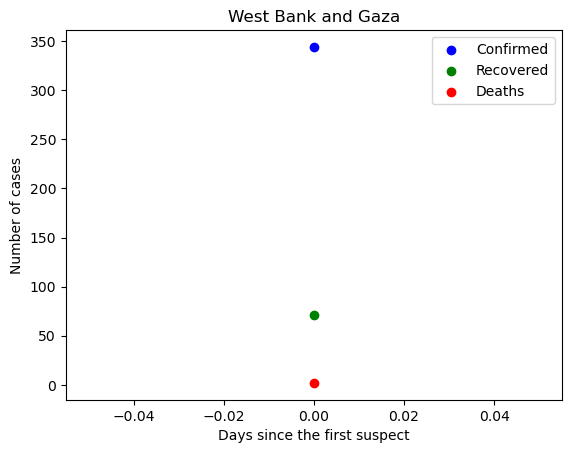

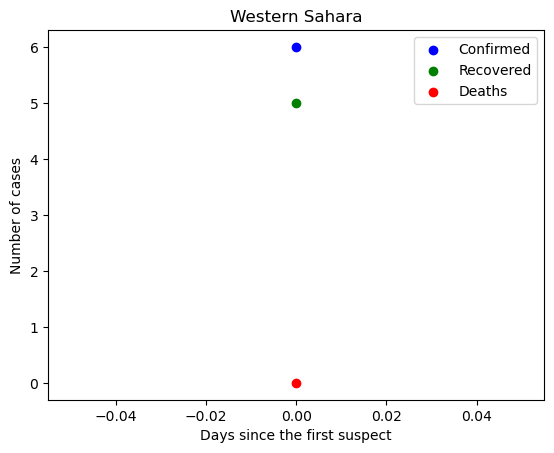

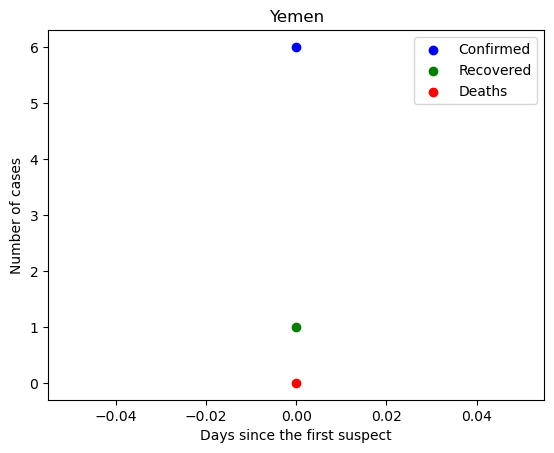

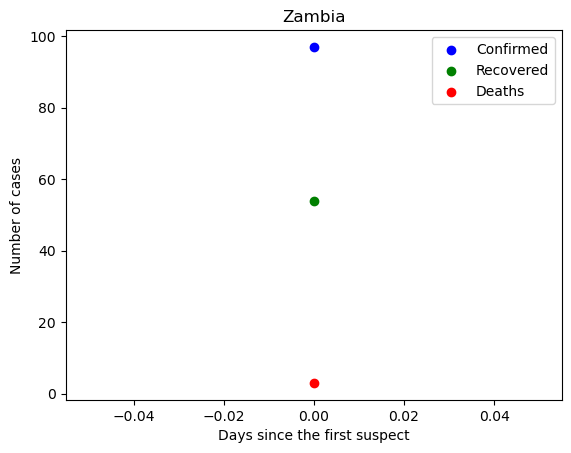

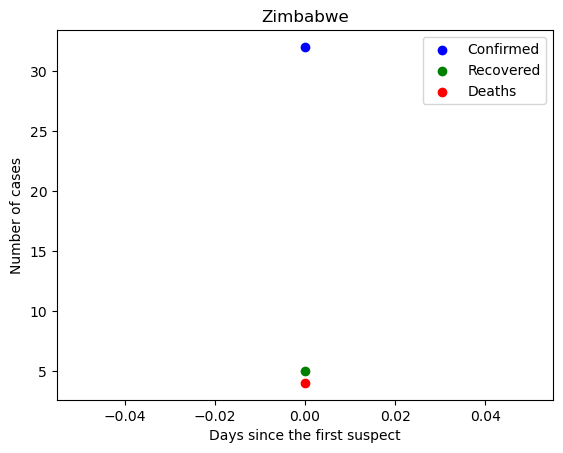

In [9]:
for idx in range(0,len(region)):    
    C = df3[df3['Region']==region[idx]].reset_index()        
    plt.scatter(np.arange(0,len(C)),C['Confirmed'],color='blue',label='Confirmed')
    plt.scatter(np.arange(0,len(C)),C['Recovered'],color='green',label='Recovered')
    plt.scatter(np.arange(0,len(C)),C['Deaths'],color='red',label='Deaths')
    plt.title(region[idx])
    plt.xlabel('Days since the first suspect')
    plt.ylabel('Number of cases')
    plt.legend()
    plt.show()    

In [10]:
df4 = df3.groupby(['Date'])[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

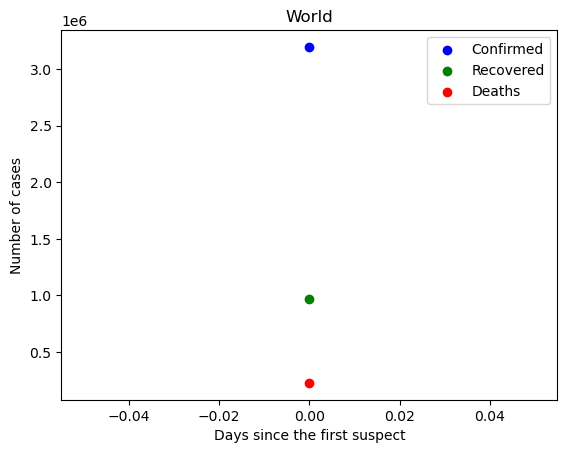

In [11]:
C = df4
plt.scatter(np.arange(0,len(C)),C['Confirmed'],color='blue',label='Confirmed')
plt.scatter(np.arange(0,len(C)),C['Recovered'],color='green',label='Recovered')
plt.scatter(np.arange(0,len(C)),C['Deaths'],color='red',label='Deaths')
plt.title('World')
plt.xlabel('Days since the first suspect')
plt.ylabel('Number of cases')
plt.legend()
plt.show()